# Forschungspraktikum — 5 October demo

This notebook presents the existing candidate-generation and analysis outputs,
then the independent synthetic value-flow and publication summaries. An optional
AF3-ReD external structure reference closes the reporting flow.

**Reading order:** input setup → structural outputs → interface analysis →
geometry and avidity surfaces → synthetic summaries → optional external provenance.
Setup and developer-check cells are labeled separately. RFdiffusion input notation
is in the appendix.

**Output boundaries:** saved outputs come from earlier runs and retain their own
input context; they are not evidence of a new end-to-end run. The synthetic
summaries do not consume the preceding design or analysis outputs. No combined
acceptance state is introduced. The external reference is optional and has no
admission or ranking effect.


## 1. Input setup and candidate generation

Use the existing RFdiffusion input panel, followed by ProteinMPNN and AlphaFold.
The structure views and download cell retain their existing behavior. Setup cells
are supporting infrastructure; they are not additional result surfaces.

<details>
<summary>Upstream notebook references</summary>

RFdiffusion generates structures with or without conditioning information such
as a motif or target. See the original [manuscript](https://www.biorxiv.org/content/10.1101/2022.12.09.519842v2).
The [upstream Colab notebook](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/main/rf/examples/diffusion.ipynb)
is a separate notebook, not this project's demo.
See also [fold conditioning](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/main/rf/examples/diffusion_foldcond.ipynb)
and the [31 March 2023 version](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/main/rf/examples/diffusion_ori.ipynb).

</details>


In [ ]:
#@title Internal setup — RFdiffusion (~8 min on first run)
%%time
import os, time, signal
import sys, random, string, re
if not os.path.isdir("params"):
  os.system("apt-get install aria2")
  os.system("mkdir params")
  # send param download into background
  os.system("(\
  aria2c -q -x 16 https://files.ipd.uw.edu/krypton/schedules.zip; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Base_ckpt.pt; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/f572d396fae9206628714fb2ce00f72e/Complex_beta_ckpt.pt; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar; \
  tar -xf alphafold_params_2022-12-06.tar -C params; \
  touch params/done.txt) &")

if not os.path.isdir("RFdiffusion"):
  print("installing RFdiffusion...")
  os.system("git clone https://github.com/sokrypton/RFdiffusion.git")
  os.system("wget -qnc https://files.ipd.uw.edu/krypton/ananas")
  os.system("chmod +x ananas")

# -----------------------------------------------------------------------------
# FIX (Sep2026): Colab now runs Python 3.13, and DGL has no py3.13 wheels.
# "pip install dgl -f data.dgl.ai/..." therefore silently falls back to the
# 2018 PyPI placeholder dgl 0.1.3 -> ImportError: cannot import name 'Mapping'
# from 'collections'.  Also, DGL's newest build targets torch 2.4, while Colab
# now ships a much newer torch.  Fix: give RFdiffusion its own isolated
# python 3.11 + torch 2.4.1(cu124) + dgl 2.4.0 env and point run_inference.py
# at it via its shebang.  The rest of the notebook stays untouched.
# -----------------------------------------------------------------------------
RF_ENV = "/content/rfdiff_env"
if not os.path.isfile(f"{RF_ENV}/bin/python"):
  print("building isolated RFdiffusion env (python3.11 + torch2.4 + dgl2.4)...")
  os.system("pip -q uninstall -y dgl")           # remove the broken 0.1.3 fallback
  os.system("pip -q install uv")
  os.system("uv python install 3.11")
  os.system(f"uv venv --python 3.11 {RF_ENV}")
  PIP = f"uv pip install -q --python {RF_ENV}/bin/python"
  os.system(f"{PIP} 'numpy<2' 'scipy<1.14' pandas networkx requests tqdm psutil pydantic packaging")
  os.system(f"{PIP} torch==2.4.1 --index-url https://download.pytorch.org/whl/cu124")
  os.system(f"{PIP} --no-deps dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html")
  os.system(f"{PIP} --no-deps torchdata")
  os.system(f"{PIP} hydra-core omegaconf icecream pyrsistent pynvml decorator")
  os.system(f"{PIP} --no-deps e3nn==0.5.5 opt_einsum opt_einsum_fx")
  os.system(f"{PIP} git+https://github.com/NVIDIA/dllogger#egg=dllogger")
  os.system(f"{PIP} --no-deps ./RFdiffusion/env/SE3Transformer")
  test = "import torch,dgl,e3nn,se3_transformer as s; print('env OK | torch',torch.__version__,'| dgl',dgl.__version__,'| cuda',torch.cuda.is_available())"
  print(os.popen(f'{RF_ENV}/bin/python -c "{test}" 2>&1 | tail -3').read())

# run_inference.py is launched as ./RFdiffusion/run_inference.py, so its
# shebang decides which python is used -> send it to the isolated env.
os.system(f"sed -i '1s|.*|#!{RF_ENV}/bin/python|' RFdiffusion/run_inference.py")
os.system("chmod +x RFdiffusion/run_inference.py")

if not os.path.isdir("colabdesign"):
  print("installing ColabDesign...")
  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")

if not os.path.isdir("RFdiffusion/models"):
  print("downloading RFdiffusion params...")
  os.system("mkdir RFdiffusion/models")
  models = ["Base_ckpt.pt","Complex_base_ckpt.pt","Complex_beta_ckpt.pt"]
  for m in models:
    while os.path.isfile(f"{m}.aria2"):
      time.sleep(5)
  os.system(f"mv {' '.join(models)} RFdiffusion/models")
  os.system("unzip schedules.zip; rm schedules.zip")

if 'RFdiffusion' not in sys.path:
  os.environ["DGLBACKEND"] = "pytorch"
  sys.path.append('RFdiffusion')

from google.colab import files
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets
import py3Dmol

# `from inference.utils import parse_pdb` would import diffusion -> dgl, which
# does not exist for the colab kernel any more.  parse_pdb only needs util.py
# (numpy/torch/scipy only), so it is inlined verbatim from RFdiffusion here.
import util

def parse_pdb(filename, **kwargs):
    """extract xyz coords for all heavy atoms"""
    lines = open(filename, "r").readlines()
    return parse_pdb_lines(lines, **kwargs)


def parse_pdb_lines(lines, parse_hetatom=False, ignore_het_h=True):
    # indices of residues observed in the structure
    res, pdb_idx = [],[]
    for l in lines:
      if l[:4] == "ATOM" and l[12:16].strip() == "CA":
        res.append((l[22:26], l[17:20]))
        # chain letter, res num
        pdb_idx.append((l[21:22].strip(), int(l[22:26].strip())))
    seq = [util.aa2num[r[1]] if r[1] in util.aa2num.keys() else 20 for r in res]

    # 4 BB + up to 10 SC atoms
    xyz = np.full((len(res), 14, 3), np.nan, dtype=np.float32)
    for l in lines:
        if l[:4] != "ATOM":
            continue
        chain, resNo, atom, aa = (
            l[21:22],
            int(l[22:26]),
            " " + l[12:16].strip().ljust(3),
            l[17:20],
        )
        if (chain,resNo) in pdb_idx:
          idx = pdb_idx.index((chain, resNo))
          # for i_atm, tgtatm in enumerate(util.aa2long[util.aa2num[aa]]):
          for i_atm, tgtatm in enumerate(
              util.aa2long[util.aa2num[aa]][:14]
          ):  # Nate's proposed change
              if (
                  tgtatm is not None and tgtatm.strip() == atom.strip()
              ):  # ignore whitespace
                  xyz[idx, i_atm, :] = [float(l[30:38]), float(l[38:46]), float(l[46:54])]
                  break

    # save atom mask
    mask = np.logical_not(np.isnan(xyz[..., 0]))
    xyz[np.isnan(xyz[..., 0])] = 0.0

    # remove duplicated (chain, resi)
    new_idx = []
    i_unique = []
    for i, idx in enumerate(pdb_idx):
        if idx not in new_idx:
            new_idx.append(idx)
            i_unique.append(i)

    pdb_idx = new_idx
    xyz = xyz[i_unique]
    mask = mask[i_unique]

    seq = np.array(seq)[i_unique]

    out = {
        "xyz": xyz,  # cartesian coordinates, [Lx14]
        "mask": mask,  # mask showing which atoms are present in the PDB file, [Lx14]
        "idx": np.array(
            [i[1] for i in pdb_idx]
        ),  # residue numbers in the PDB file, [L]
        "seq": np.array(seq),  # amino acid sequence, [L]
        "pdb_idx": pdb_idx,  # list of (chain letter, residue number) in the pdb file, [L]
    }

    # heteroatoms (ligands, etc)
    if parse_hetatom:
        xyz_het, info_het = [], []
        for l in lines:
            if l[:6] == "HETATM" and not (ignore_het_h and l[77] == "H"):
                info_het.append(
                    dict(
                        idx=int(l[7:11]),
                        atom_id=l[12:16],
                        atom_type=l[77],
                        name=l[16:20],
                    )
                )
                xyz_het.append([float(l[30:38]), float(l[38:46]), float(l[46:54])])

        out["xyz_het"] = np.array(xyz_het)
        out["info_het"] = info_het

    return out

from colabdesign.rf.utils import get_ca
from colabdesign.rf.utils import fix_contigs, fix_partial_contigs, fix_pdb, sym_it
from colabdesign.shared.protein import pdb_to_string
from colabdesign.shared.plot import plot_pseudo_3D

def get_pdb(pdb_code=None):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    if not os.path.isfile(f"{pdb_code}.pdb1"):
      os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.pdb1.gz")
      os.system(f"gunzip {pdb_code}.pdb1.gz")
    return f"{pdb_code}.pdb1"
  else:
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb")
    return f"AF-{pdb_code}-F1-model_v3.pdb"

def run_ananas(pdb_str, path, sym=None):
  pdb_filename = f"outputs/{path}/ananas_input.pdb"
  out_filename = f"outputs/{path}/ananas.json"
  with open(pdb_filename,"w") as handle:
    handle.write(pdb_str)

  cmd = f"./ananas {pdb_filename} -u -j {out_filename}"
  if sym is None: os.system(cmd)
  else: os.system(f"{cmd} {sym}")

  # parse results
  try:
    out = json.loads(open(out_filename,"r").read())
    results,AU = out[0], out[-1]["AU"]
    group = AU["group"]
    chains = AU["chain names"]
    rmsd = results["Average_RMSD"]
    print(f"AnAnaS detected {group} symmetry at RMSD:{rmsd:.3}")

    C = np.array(results['transforms'][0]['CENTER'])
    A = [np.array(t["AXIS"]) for t in results['transforms']]

    # apply symmetry and filter to the asymmetric unit
    new_lines = []
    for line in pdb_str.split("\n"):
      if line.startswith("ATOM"):
        chain = line[21:22]
        if chain in chains:
          x = np.array([float(line[i:(i+8)]) for i in [30,38,46]])
          if group[0] == "c":
            x = sym_it(x,C,A[0])
          if group[0] == "d":
            x = sym_it(x,C,A[1],A[0])
          coord_str = "".join(["{:8.3f}".format(a) for a in x])
          new_lines.append(line[:30]+coord_str+line[54:])
      else:
        new_lines.append(line)
    return results, "\n".join(new_lines)

  except:
    return None, pdb_str

def run(command, steps, num_designs=1, visual="none"):

  def run_command_and_get_pid(command):
    pid_file = '/dev/shm/pid'
    os.system(f'nohup {command} & echo $! > {pid_file}')
    with open(pid_file, 'r') as f:
      pid = int(f.read().strip())
    os.remove(pid_file)
    return pid
  def is_process_running(pid):
    try:
      os.kill(pid, 0)
    except OSError:
      return False
    else:
      return True

  run_output = widgets.Output()
  progress = widgets.FloatProgress(min=0, max=1, description='running', bar_style='info')
  display(widgets.VBox([progress, run_output]))

  # clear previous run
  for n in range(steps):
    if os.path.isfile(f"/dev/shm/{n}.pdb"):
      os.remove(f"/dev/shm/{n}.pdb")

  pid = run_command_and_get_pid(command)
  try:
    fail = False
    for _ in range(num_designs):

      # for each step check if output generated
      for n in range(steps):
        wait = True
        while wait and not fail:
          time.sleep(0.1)
          if os.path.isfile(f"/dev/shm/{n}.pdb"):
            pdb_str = open(f"/dev/shm/{n}.pdb").read()
            if pdb_str[-3:] == "TER":
              wait = False
            elif not is_process_running(pid):
              fail = True
          elif not is_process_running(pid):
            fail = True

        if fail:
          progress.bar_style = 'danger'
          progress.description = "failed"
          break

        else:
          progress.value = (n+1) / steps
          if visual != "none":
            with run_output:
              run_output.clear_output(wait=True)
              if visual == "image":
                xyz, bfact = get_ca(f"/dev/shm/{n}.pdb", get_bfact=True)
                fig = plt.figure()
                fig.set_dpi(100);fig.set_figwidth(6);fig.set_figheight(6)
                ax1 = fig.add_subplot(111);ax1.set_xticks([]);ax1.set_yticks([])
                plot_pseudo_3D(xyz, c=bfact, cmin=0.5, cmax=0.9, ax=ax1)
                plt.show()
              if visual == "interactive":
                view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
                view.addModel(pdb_str,'pdb')
                view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':0.5,'max':0.9}}})
                view.zoomTo()
                view.show()
        if os.path.exists(f"/dev/shm/{n}.pdb"):
          os.remove(f"/dev/shm/{n}.pdb")
      if fail:
        progress.bar_style = 'danger'
        progress.description = "failed"
        break

    while is_process_running(pid):
      time.sleep(0.1)

  except KeyboardInterrupt:
    os.kill(pid, signal.SIGTERM)
    progress.bar_style = 'danger'
    progress.description = "stopped"

def run_diffusion(contigs, path, pdb=None, iterations=50,
                  symmetry="none", order=1, hotspot=None,
                  chains=None, add_potential=False, partial_T="auto",
                  num_designs=1, use_beta_model=False, visual="none"):

  full_path = f"outputs/{path}"
  os.makedirs(full_path, exist_ok=True)
  opts = [f"inference.output_prefix={full_path}",
          f"inference.num_designs={num_designs}"]

  if chains == "": chains = None

  # determine symmetry type
  if symmetry in ["auto","cyclic","dihedral"]:
    if symmetry == "auto":
      sym, copies = None, 1
    else:
      sym, copies = {"cyclic":(f"c{order}",order),
                     "dihedral":(f"d{order}",order*2)}[symmetry]
  else:
    symmetry = None
    sym, copies = None, 1

  # determine mode
  contigs = contigs.replace(","," ").replace(":"," ").split()
  is_fixed, is_free = False, False
  fixed_chains = []
  for contig in contigs:
    for x in contig.split("/"):
      a = x.split("-")[0]
      if a[0].isalpha():
        is_fixed = True
        if a[0] not in fixed_chains:
          fixed_chains.append(a[0])
      if a.isnumeric():
        is_free = True
  if len(contigs) == 0 or not is_free:
    mode = "partial"
  elif is_fixed:
    mode = "fixed"
  else:
    mode = "free"

  # fix input contigs
  if mode in ["partial","fixed"]:
    pdb_str = pdb_to_string(get_pdb(pdb), chains=chains)
    if symmetry == "auto":
      a, pdb_str = run_ananas(pdb_str, path)
      if a is None:
        print(f'ERROR: no symmetry detected')
        symmetry = None
        sym, copies = None, 1
      else:
        if a["group"][0] == "c":
          symmetry = "cyclic"
          sym, copies = a["group"], int(a["group"][1:])
        elif a["group"][0] == "d":
          symmetry = "dihedral"
          sym, copies = a["group"], 2 * int(a["group"][1:])
        else:
          print(f'ERROR: the detected symmetry ({a["group"]}) not currently supported')
          symmetry = None
          sym, copies = None, 1

    elif mode == "fixed":
      pdb_str = pdb_to_string(pdb_str, chains=fixed_chains)

    pdb_filename = f"{full_path}/input.pdb"
    with open(pdb_filename, "w") as handle:
      handle.write(pdb_str)

    parsed_pdb = parse_pdb(pdb_filename)
    opts.append(f"inference.input_pdb={pdb_filename}")
    if mode in ["partial"]:
      if partial_T == "auto":
        iterations = int(80 * (iterations / 200))
      else:
        iterations = int(partial_T)
      opts.append(f"diffuser.partial_T={iterations}")
      contigs = fix_partial_contigs(contigs, parsed_pdb)
    else:
      opts.append(f"diffuser.T={iterations}")
      contigs = fix_contigs(contigs, parsed_pdb)
  else:
    opts.append(f"diffuser.T={iterations}")
    parsed_pdb = None
    contigs = fix_contigs(contigs, parsed_pdb)

  if hotspot is not None and hotspot != "":
    hotspot = ",".join(hotspot.replace(","," ").split())
    opts.append(f"ppi.hotspot_res='[{hotspot}]'")

  # setup symmetry
  if sym is not None:
    sym_opts = ["--config-name symmetry", f"inference.symmetry={sym}"]
    if add_potential:
      sym_opts += ["'potentials.guiding_potentials=[\"type:olig_contacts,weight_intra:1,weight_inter:0.1\"]'",
                   "potentials.olig_intra_all=True","potentials.olig_inter_all=True",
                   "potentials.guide_scale=2","potentials.guide_decay=quadratic"]
    opts = sym_opts + opts
    contigs = sum([contigs] * copies,[])

  opts.append(f"'contigmap.contigs=[{' '.join(contigs)}]'")
  opts += ["inference.dump_pdb=True","inference.dump_pdb_path='/dev/shm'"]
  if use_beta_model:
    opts += ["inference.ckpt_override_path=./RFdiffusion/models/Complex_beta_ckpt.pt"]

  print("mode:", mode)
  print("output:", full_path)
  print("contigs:", contigs)

  opts_str = " ".join(opts)
  cmd = f"./RFdiffusion/run_inference.py {opts_str}"
  print(cmd)

  # RUN
  run(cmd, iterations, num_designs, visual=visual)

  # fix pdbs
  for n in range(num_designs):
    pdbs = [f"outputs/traj/{path}_{n}_pX0_traj.pdb",
            f"outputs/traj/{path}_{n}_Xt-1_traj.pdb",
            f"{full_path}_{n}.pdb"]
    for pdb in pdbs:
      with open(pdb,"r") as handle: pdb_str = handle.read()
      with open(pdb,"w") as handle: handle.write(fix_pdb(pdb_str, contigs))

  return contigs, copies

installing RFdiffusion...
building isolated RFdiffusion env (python3.11 + torch2.4 + dgl2.4)...
DGL backend not selected or invalid.  Assuming PyTorch for now.
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
env OK | torch 2.4.1+cu124 | dgl 2.4.0+cu124 | cuda True

installing ColabDesign...
downloading RFdiffusion params...
CPU times: user 3.39 s, sys: 545 ms, total: 3.94 s
Wall time: 3min 36s


In [ ]:
#@title Internal setup — prepare the existing trajectory directory
import os
os.makedirs("/content/outputs/traj/test_run", exist_ok=True)


In [ ]:
%%time
#@title Generate a backbone with RFdiffusion
name = "test_run" #@param {type:"string"}
contigs = "A 10-50:30" #@param {type:"string"}
pdb = "1YKO" #@param {type:"string"}
iterations = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
hotspot = "A20,A25,A30" #@param {type:"string"}
num_designs = 2 #@param ["1", "2", "4", "8", "16", "32"] {type:"raw"}
visual = "image" #@param ["none", "image", "interactive"]
#@markdown ---
#@markdown **symmetry** settings
#@markdown ---
symmetry = "none" #@param ["none", "auto", "cyclic", "dihedral"]
order = 1 #@param ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"] {type:"raw"}
chains = "" #@param {type:"string"}
add_potential = True #@param {type:"boolean"}
#@markdown - `symmetry='auto'` enables automatic symmetry dectection with [AnAnaS](https://team.inria.fr/nano-d/software/ananas/).
#@markdown - `chains="A,B"` filter PDB input to these chains (may help auto-symm detector)
#@markdown - `add_potential` to discourage clashes between chains
#@markdown ---
#@markdown **advanced** settings
#@markdown ---
partial_T = "auto" # @param ["auto", "10", "20", "40", "60", "80"]
#@markdown - specify number of noising steps (only used for the partial diffusion protocol)
use_beta_model = False #@param {type:"boolean"}
#@markdown - if you are seeing lots of helices, switch to the "beta" params for a better SSE balance.

# determine where to save
path = name
while os.path.exists(f"outputs/{path}_0.pdb"):
  path = name + "_" + ''.join(random.choices(string.ascii_lowercase + string.digits, k=5))

flags = {"contigs":contigs,
         "pdb":pdb,
         "order":order,
         "iterations":iterations,
         "symmetry":symmetry,
         "hotspot":hotspot,
         "path":path,
         "chains":chains,
         "add_potential":add_potential,
         "num_designs":num_designs,
         "use_beta_model":use_beta_model,
         "visual":visual,
         "partial_T":partial_T}

for k,v in flags.items():
  if isinstance(v,str):
    flags[k] = v.replace("'","").replace('"','')

contigs, copies = run_diffusion(**flags)

mode: fixed
output: outputs/test_run
contigs: ['A1-200', '34-34', '30-30']
./RFdiffusion/run_inference.py inference.output_prefix=outputs/test_run inference.num_designs=2 inference.input_pdb=outputs/test_run/input.pdb diffuser.T=50 ppi.hotspot_res='[A20,A25,A30]' 'contigmap.contigs=[A1-200 34-34 30-30]' inference.dump_pdb=True inference.dump_pdb_path='/dev/shm'


CPU times: user 27.6 s, sys: 354 ms, total: 27.9 s
Wall time: 7min 12s


In [ ]:
#@title Display 3D structure {run: "auto"}
animate = "interactive" #@param ["none", "movie", "interactive"]
color = "rainbow" #@param ["rainbow", "chain", "plddt"]
denoise = True
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}
from colabdesign.shared.plot import pymol_color_list
from colabdesign.rf.utils import get_ca, get_Ls, make_animation
from string import ascii_uppercase,ascii_lowercase
alphabet_list = list(ascii_uppercase+ascii_lowercase)

def plot_pdb(num=0):
  if denoise:
    pdb_traj = f"outputs/traj/{path}_{num}_pX0_traj.pdb"
  else:
    pdb_traj = f"outputs/traj/{path}_{num}_Xt-1_traj.pdb"
  if animate in ["none","interactive"]:
    hbondCutoff = 4.0
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
    if animate == "interactive":
      pdb_str = open(pdb_traj,'r').read()
      view.addModelsAsFrames(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    else:
      pdb = f"outputs/{path}_{num}.pdb"
      pdb_str = open(pdb,'r').read()
      view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    if color == "rainbow":
      view.setStyle({'cartoon': {'color':'spectrum'}})
    elif color == "chain":
      for n,chain,c in zip(range(len(contigs)),
                              alphabet_list,
                              pymol_color_list):
          view.setStyle({'chain':chain},{'cartoon': {'color':c}})
    else:
      view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':0.5,'max':0.9}}})
    view.zoomTo()
    if animate == "interactive":
      view.animate({'loop': 'backAndForth'})
    view.show()
  else:
    Ls = get_Ls(contigs)
    xyz, bfact = get_ca(pdb_traj, get_bfact=True)
    xyz = xyz.reshape((-1,sum(Ls),3))[::-1]
    bfact = bfact.reshape((-1,sum(Ls)))[::-1]
    if color == "chain":
      display(HTML(make_animation(xyz, Ls=Ls, dpi=dpi, ref=-1)))
    elif color == "rainbow":
      display(HTML(make_animation(xyz, dpi=dpi, ref=-1)))
    else:
      display(HTML(make_animation(xyz, plddt=bfact*100, dpi=dpi, ref=-1)))


if num_designs > 1:
  output = widgets.Output()
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
      options=[(f'{k}',k) for k in range(num_designs)],
      value=0, description='design:',
  )
  dropdown.observe(on_change)
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

In [ ]:
#@title Internal setup — JAX compatibility
# === JAX compatibility patch: jnp.clip(a_min=, a_max=) ===
# ColabDesign's AlphaFold modules call jnp.clip(..., a_min=, a_max=).
# Current JAX removed these arguments, so designability_test.py raises the following
# error during AlphaFold: "TypeError: clip() got an unexpected keyword argument 'a_max'".
# The notebook and subprocess may use different colabdesign copies, so
# all installed copies are patched. Run once after setup.

import os, re, glob, inspect, subprocess
import jax.numpy as jnp

if "a_min" in inspect.signature(jnp.clip).parameters:
    print("This JAX version accepts a_min/a_max; no patch is needed.")
else:
    roots = set()
    for pat in ["/content/colabdesign",
                "/usr/local/lib/python*/dist-packages/colabdesign",
                "/usr/local/lib/python*/site-packages/colabdesign",
                "/usr/lib/python3*/dist-packages/colabdesign"]:
        for p in glob.glob(pat):
            if os.path.isfile(os.path.join(p, "__init__.py")):
                roots.add(p)

    rels = ["af/alphafold/model/modules.py", "af/alphafold/model/modules_multimer.py"]
    total = 0
    for root in sorted(roots):
        for rel in rels:
            f = os.path.join(root, rel)
            if not os.path.isfile(f):
                continue
            src = open(f).read()
            new, n1 = re.subn(r"\ba_min\s*=", "min=", src)
            new, n2 = re.subn(r"\ba_max\s*=", "max=", new)
            if n1 + n2:
                if not os.path.exists(f + ".bak"):
                    open(f + ".bak", "w").write(src)   # retain the original
                open(f, "w").write(new)
            total += n1 + n2
            print(f, "->", n1 + n2, "changes")
    print("Total", total, "patches applied. Copies:", sorted(roots))

# verify that the subprocess sees the patched source
chk = subprocess.run(["python", "-c",
    "import colabdesign.af.alphafold.model.modules as m, inspect;"
    "s=inspect.getsource(m);"
    "print(m.__file__);"
    "print('REMAINING a_min/a_max:', s.count('a_min=') + s.count('a_max='))"],
    capture_output=True, text=True, cwd="/content/colabdesign/rf")
print(chk.stdout.strip() or chk.stderr.strip()[-800:])


/content/colabdesign/af/alphafold/model/modules.py -> 0 changes
/content/colabdesign/af/alphafold/model/modules_multimer.py -> 0 changes
/usr/local/lib/python3.13/dist-packages/colabdesign/af/alphafold/model/modules.py -> 0 changes
/usr/local/lib/python3.13/dist-packages/colabdesign/af/alphafold/model/modules_multimer.py -> 0 changes
Total 0 patches applied. Copies: ['/content/colabdesign', '/usr/local/lib/python3.13/dist-packages/colabdesign']
/usr/local/lib/python3.13/dist-packages/colabdesign/af/alphafold/model/modules.py
REMAINING a_min/a_max: 0


In [ ]:
%%time
#@title Generate sequences with ProteinMPNN and check structures with AlphaFold
#@markdown ProteinMPNN Settings
num_seqs = 8 #@param ["1", "2", "4", "8", "16", "32", "64"] {type:"raw"}
mpnn_sampling_temp = 0.1 #@param ["0.0001", "0.1", "0.15", "0.2", "0.25", "0.3", "0.5", "1.0"] {type:"raw"}
rm_aa = "C" #@param {type:"string"}
use_solubleMPNN = False #@param {type:"boolean"}
#@markdown - `mpnn_sampling_temp` - control diversity of sampled sequences. (higher = more diverse).
#@markdown - `rm_aa='C'` - do not use [C]ysteines.
#@markdown - `use_solubleMPNN` - use weights trained only on soluble proteins. See [preprint](https://www.biorxiv.org/content/10.1101/2023.05.09.540044v2).
#@markdown
#@markdown AlphaFold Settings
initial_guess = True #@param {type:"boolean"}
#@markdown - soft initialization with desired coordinates, see [paper](https://www.nature.com/articles/s41467-023-38328-5).
num_recycles = 3 #@param ["0", "1", "2", "3", "6", "12"] {type:"raw"}
#@markdown - for **binder** design, we recommend `initial_guess=True num_recycles=3`
use_multimer = False #@param {type:"boolean"}
#@markdown - `use_multimer` - use AlphaFold Multimer v3 params for prediction.

if not os.path.isfile("params/done.txt"):
  print("downloading AlphaFold params...")
  while not os.path.isfile("params/done.txt"):
    time.sleep(5)

contigs_str = ":".join(contigs)
opts = [f"--pdb=outputs/{path}_0.pdb",
        f"--loc=outputs/{path}",
        f"--contig={contigs_str}",
        f"--copies={copies}",
        f"--num_seqs={num_seqs}",
        f"--num_recycles={num_recycles}",
        f"--rm_aa={rm_aa}",
        f"--mpnn_sampling_temp={mpnn_sampling_temp}",
        f"--num_designs={num_designs}"]
if initial_guess: opts.append("--initial_guess")
if use_multimer: opts.append("--use_multimer")
if use_solubleMPNN: opts.append("--use_soluble")
opts = ' '.join(opts)
!python colabdesign/rf/designability_test.py {opts}

{'pdb':'outputs/test_run_0.pdb','loc':'outputs/test_run','contigs':'A1-200:34-34:30-30','copies':1,'num_seqs':8,'initial_guess':True,'use_multimer':False,'use_soluble':False,'num_recycles':3,'rm_aa':'C','num_designs':2,'mpnn_sampling_temp':0.1}
protocol=binder
running proteinMPNN...
running AlphaFold...
design:0 n:0 mpnn:1.101 plddt:0.854 i_ptm:0.117 i_pae:26.339 rmsd:13.798 PIELLPETPSQTAGPYVHIGLALEAAGNPTRDQEIWNRLAKPDAPGEHILLLGQVYDGNGHLVRDSFLEVWQADANGEYQDAYNLENAFNSFGRTATTFDAGEWTLHTVKPGVVNNAAGVPMAPHINISLFARGINIHLHTRLYFDDEAQANAKCPVLNLIEQPQRRETLIAKRCEVDGKTAYRFDIRIQGEGETVFFDF/AAAARAARRAALEARIAAQEARAAALEAEAAAAEAAAAADRARALERAKALAARARAELAALKA
design:0 n:1 mpnn:1.180 plddt:0.861 i_ptm:0.102 i_pae:27.463 rmsd:24.681 PIELLPETPSQTAGPYVHIGLALEAAGNPTRDQEIWNRLAKPDAPGEHILLLGQVYDGNGHLVRDSFLEVWQADANGEYQDAYNLENAFNSFGRTATTFDAGEWTLHTVKPGVVNNAAGVPMAPHINISLFARGINIHLHTRLYFDDEAQANAKCPVLNLIEQPQRRETLIAKRCEVDGKTAYRFDIRIQGEGETVFFDF/AAAALAARRARLRATIKKNRKAAAALEAAAAAAKAAAAAAFAAALAGARAREARARAELAALDA
design:0 n:2 mpnn

In [ ]:
#@title Display best result
import py3Dmol
def plot_pdb(num = "best"):
  if num == "best":
    with open(f"outputs/{path}/best.pdb","r") as f:
      # REMARK 001 design {m} N {n} RMSD {rmsd}
      info = f.readline().strip('\n').split()
    num = info[3]
  hbondCutoff = 4.0
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
  pdb_str = open(f"outputs/{path}_{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
  pdb_str = open(f"outputs/{path}/best_design{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})

  view.setStyle({"model":0},{'cartoon':{}}) #: {'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.setStyle({"model":1},{'cartoon':{'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.zoomTo()
  view.show()

if num_designs > 1:
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
    options=["best"] + [str(k) for k in range(num_designs)],
    value="best",
    description='design:',
  )
  dropdown.observe(on_change)
  output = widgets.Output()
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

In [ ]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive,
#@markdown try disabling your adblocker and run this cell again.
#@markdown  If that fails click on the little folder icon to the
#@markdown  left, navigate to file: `name.result.zip`,
#@markdown  right-click and select \"Download\"
#@markdown (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).
!zip -r {path}.result.zip outputs/{path}* outputs/traj/{path}*
files.download(f"{path}.result.zip")

  adding: outputs/test_run/ (stored 0%)
  adding: outputs/test_run/all_pdb/ (stored 0%)
  adding: outputs/test_run/design.fasta (stored 0%)
  adding: outputs/test_run/input.pdb (deflated 74%)
  adding: outputs/test_run_0.pdb (deflated 76%)
  adding: outputs/test_run_0.trb (deflated 38%)
  adding: outputs/test_run_1.pdb (deflated 76%)
  adding: outputs/test_run_1.trb (deflated 38%)
  adding: outputs/traj/test_run/ (stored 0%)
  adding: outputs/traj/test_run_0_pX0_traj.pdb (deflated 76%)
  adding: outputs/traj/test_run_0_Xt-1_traj.pdb (deflated 76%)
  adding: outputs/traj/test_run_1_pX0_traj.pdb (deflated 76%)
  adding: outputs/traj/test_run_1_Xt-1_traj.pdb (deflated 76%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Existing structural prediction outputs

The Boltz-2 input, run and comparison cells retain the existing design selection
and output handling. Read their outputs in that selected design's context;
these cells do not consume the optional AF3-ReD reference.

In [ ]:
#@title Internal setup — Boltz-2 (isolated environment; first run takes a few minutes)
# Boltz requires python >=3.10,<3.13 and numpy<2. The main Colab environment uses python3.13 + numpy2,
# so installation there would fail and disrupt the RFdiffusion/AlphaFold setup.
# Use a separate python3.11 virtual environment and invoke boltz from there.

import os, sys, subprocess, time, torch

BOLTZ_ENV = "/content/boltz_env"
BOLTZ_BIN = BOLTZ_ENV + "/bin/boltz"

cap = torch.cuda.get_device_capability() if torch.cuda.is_available() else (0, 0)
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "unavailable"
# cuEquivariance kernels require Ampere (8.0) or later; T4 = 7.5, so disable them there
USE_KERNELS = cap[0] >= 8
print("GPU:", gpu_name, "| compute capability", str(cap[0]) + "." + str(cap[1]),
      "| accelerated kernels:", USE_KERNELS)

if not os.path.isfile(BOLTZ_BIN):
    t0 = time.time()
    print("Installing uv...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    print("Creating a python3.11 virtual environment...")
    subprocess.run([sys.executable, "-m", "uv", "venv", "--python", "3.11", BOLTZ_ENV], check=True)
    pkg = "boltz[cuda]" if USE_KERNELS else "boltz"
    print(pkg, "is being installed; this step takes a few minutes...")
    subprocess.run([sys.executable, "-m", "uv", "pip", "install",
                    "--python", BOLTZ_ENV + "/bin/python", pkg], check=True)
    print("Setup completed:", round(time.time() - t0), "s")
else:
    print("Boltz is already installed; skipping setup")

chk = subprocess.run([BOLTZ_BIN, "--help"], capture_output=True, text=True)
print("boltz CLI:", "ready" if chk.returncode == 0 else "ERROR")
print((chk.stdout or chk.stderr)[:300])

GPU: Tesla T4 | compute capability 7.5 | accelerated kernels: False
Installing uv...
Creating a python3.11 virtual environment...
boltz is being installed; this step takes a few minutes...
Setup completed: 64 s
boltz CLI: ready
Usage: boltz [OPTIONS] COMMAND [ARGS]...

  Boltz.

Options:
  --help  Show this message and exit.

Commands:
  predict  Run predictions with Boltz.



In [ ]:
#@title Prepare Boltz-2 input (YAML from the selected best design)
rank_by = "rmsd" #@param ["rmsd", "i_ptm", "plddt"]
#@markdown - Select the lowest `rmsd`, or the highest `i_ptm` or `plddt` row.

import os, pandas as pd, yaml

csv_path = "outputs/" + path + "/mpnn_results.csv"
df = pd.read_csv(csv_path)
best = df.sort_values(rank_by, ascending=(rank_by == "rmsd")).iloc[0]
print(df[["design","n","mpnn","plddt","i_ptm","i_pae","rmsd"]].to_string(index=False))
print()
print("selected design: design", int(best["design"]), "/ n", int(best["n"]),
      "|", rank_by, "=", round(float(best[rank_by]), 3))

chain_seqs = best["seq"].split("/")
chain_ids = [chr(ord("A") + i) for i in range(len(chain_seqs))]

# In contigs, a segment starting with a letter is the target chain from the PDB;
# segments starting with a digit are binder chains designed by RFdiffusion.
is_target = [c[0].isalpha() for c in contigs]
if len(is_target) != len(chain_seqs):
    is_target = [i == 0 for i in range(len(chain_seqs))]

entries = []
for cid, seq, tgt in zip(chain_ids, chain_seqs, is_target):
    d = {"id": cid, "sequence": seq}
    if not tgt:
        d["msa"] = "empty"   # de novo binder; no natural homolog is assumed, so no MSA search
    entries.append({"protein": d})
    print(" ", cid, "->", "target" if tgt else "binder", "|", len(seq), "residues")

os.makedirs("/content/boltz_in", exist_ok=True)
BOLTZ_YAML = "/content/boltz_in/" + path + "_best.yaml"
with open(BOLTZ_YAML, "w") as f:
    # use a large width to prevent PyYAML from splitting and corrupting long sequences
    yaml.safe_dump({"version": 1, "sequences": entries}, f,
                   sort_keys=False, default_flow_style=False, width=10**6)

print()
print("YAML written:", BOLTZ_YAML)
print(open(BOLTZ_YAML).read()[:600])

 design  n     mpnn    plddt    i_ptm     i_pae      rmsd
      0  0 1.100533 0.853841 0.116840 26.339328 13.797583
      0  1 1.180323 0.861498 0.102307 27.462912 24.681467
      0  2 1.197842 0.732071 0.108857 27.810986 15.580935
      0  3 1.308334 0.854789 0.101498 27.065432  9.975679
      0  4 1.284359 0.825653 0.106025 27.550495 15.216710
      0  5 1.184243 0.869567 0.115657 26.502101 12.876414
      0  6 1.061032 0.861863 0.125481 26.189763 11.603563
      0  7 1.125037 0.873180 0.110889 27.133590 10.813338
      1  0 1.115469 0.929073 0.107413 26.647741 12.463392
      1  1 1.178026 0.933698 0.112781 26.200415  9.391675
      1  2 1.071036 0.929970 0.112306 26.903265 26.275717
      1  3 1.107235 0.912964 0.111966 26.927785 21.366236
      1  4 1.083278 0.917695 0.116279 26.831782 19.837709
      1  5 1.123964 0.912825 0.123588 25.910472  7.350481
      1  6 1.039399 0.732301 0.123375 26.956598 26.024229
      1  7 1.045069 0.919025 0.117484 26.457770 20.474413

selected desi

In [ ]:
#@title Run Boltz-2 (complex structure and confidence scores)
diffusion_samples = 1 #@param ["1", "3", "5"] {type:"raw"}
boltz_recycling_steps = 3 #@param ["1", "3", "6"] {type:"raw"}
use_potentials = True #@param {type:"boolean"}
#@markdown - Model weights (~2 GB) are downloaded once on the first run.
#@markdown - `use_potentials` applies physical-plausibility potentials during inference, with some slowdown.

import os, time, subprocess

BOLTZ_OUT = "/content/boltz_out"
os.makedirs(BOLTZ_OUT, exist_ok=True)

cmd = [BOLTZ_BIN, "predict", BOLTZ_YAML,
       "--out_dir", BOLTZ_OUT,
       "--use_msa_server",
       "--output_format", "pdb",
       "--diffusion_samples", str(diffusion_samples),
       "--recycling_steps", str(boltz_recycling_steps),
       "--num_workers", "2",
       "--override"]
if use_potentials:
    cmd.append("--use_potentials")
if not USE_KERNELS:
    cmd.append("--no_kernels")   # required on pre-Ampere GPUs such as T4

print(" ".join(cmd))
print()
t0 = time.time()
p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                     text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")
p.wait()
print()
print("completed | exit code:", p.returncode, "| duration:", round(time.time() - t0), "s")

/content/boltz_env/bin/boltz predict /content/boltz_in/test_run_best.yaml --out_dir /content/boltz_out --use_msa_server --output_format pdb --diffusion_samples 1 --recycling_steps 3 --num_workers 2 --override --use_potentials --no_kernels

MSA server enabled: https://api.colabfold.com
MSA server authentication: no credentials provided
Extracting the CCD data to /root/.boltz/mols. This may take a bit of time. You may change the cache directory with the --cache flag.
Checking input data.
Processing 1 inputs with 1 threads.

  0%|          | 0/1 [00:00<?, ?it/s]Found explicit empty MSA for some proteins, will run these in single sequence mode. Keep in mind that the model predictions will be suboptimal without an MSA.
Generating MSA for /content/boltz_in/test_run_best.yaml with 1 protein entities.
Calling MSA server for target test_run_best with 1 sequences
MSA server URL: https://api.colabfold.com
MSA pairing strategy: greedy
No authentication provided for MSA server


  0%|          | 0/

In [ ]:
#@title Boltz-2 results (scores and comparison with AlphaFold)
import json, glob, os
import py3Dmol

jsons = sorted(glob.glob(BOLTZ_OUT + "/**/confidence_*_model_*.json", recursive=True))
if not jsons:
    raise FileNotFoundError("No Boltz output found. Check the preceding cell's logs: " + BOLTZ_OUT)

keys = ["confidence_score", "ptm", "iptm", "protein_iptm", "ligand_iptm",
        "complex_plddt", "complex_iplddt", "complex_pde", "complex_ipde"]

print("Boltz-2 confidence scores")
print("-" * 62)
for j in jsons:
    d = json.load(open(j))
    print(os.path.basename(j))
    for k in keys:
        v = d.get(k)
        if isinstance(v, (int, float)):
            print("   {:18s} {:.3f}".format(k, v))
    pc = d.get("pair_chains_iptm")
    if pc:
        print("   chain-pair ipTM:")
        for a in pc:
            for b in pc[a]:
                if a < b:
                    print("      {}-{}: {:.3f}".format(a, b, float(pc[a][b])))
    print()

print("-" * 62)
print("AlphaFold (designability_test) scores for the same design:")
print("   i_ptm {:.3f} | plddt {:.3f} | i_pae {:.2f} | rmsd {:.2f} A".format(
      float(best["i_ptm"]), float(best["plddt"]), float(best["i_pae"]), float(best["rmsd"])))
print()
print("Note: the Boltz-2 affinity module applies only to protein–small-molecule complexes.")
print("It provides no numerical affinity for protein–protein binders; ipTM and PAE are used as proxy measures.")

# 3D comparison: Boltz-2 prediction (pLDDT colors) over the RFdiffusion backbone (gray)
structs = sorted(glob.glob(BOLTZ_OUT + "/**/*_model_0.pdb", recursive=True))
fmt = "pdb"
if not structs:
    structs = sorted(glob.glob(BOLTZ_OUT + "/**/*_model_0.cif", recursive=True))
    fmt = "cif"
print("structure files found:", [os.path.relpath(s, BOLTZ_OUT) for s in structs])
if structs:
    txt = open(structs[0]).read()
    bf = [float(l[60:66]) for l in txt.splitlines() if l.startswith("ATOM")]
    lo, hi = (min(bf), max(bf)) if bf else (0, 1)
    view = py3Dmol.view(js="https://3dmol.org/build/3Dmol.js")
    view.addModel(open("outputs/" + path + "_" + str(int(best["design"])) + ".pdb").read(), "pdb")
    view.addModel(txt, fmt)
    view.setStyle({"model": 0}, {"cartoon": {"color": "lightgray"}})
    if bf:
        view.setStyle({"model": 1}, {"cartoon": {"colorscheme":
                      {"prop": "b", "gradient": "roygb", "min": lo, "max": hi}}})
    else:
        view.setStyle({"model": 1}, {"cartoon": {"color": "spectrum"}})
    view.zoomTo()
    view.show()
    print("gray = RFdiffusion backbone; colored = Boltz-2 prediction")
else:
    print("No structure file found. Files under BOLTZ_OUT:")
    for r, d, fs in os.walk(BOLTZ_OUT):
        for fn in fs:
            print("  ", os.path.relpath(os.path.join(r, fn), BOLTZ_OUT))

Boltz-2 confidence scores
--------------------------------------------------------------
confidence_test_run_best_model_0.json
   confidence_score   0.774
   ptm                0.720
   iptm               0.060
   protein_iptm       0.060
   ligand_iptm        0.000
   complex_plddt      0.952
   complex_iplddt     0.952
   complex_pde        1.084
   complex_ipde       17.575
   chain-pair ipTM:
      0-1: 0.059

--------------------------------------------------------------
AlphaFold (designability_test) scores for the same design:
   i_ptm 0.124 | plddt 0.913 | i_pae 25.91 | rmsd 7.35 A

Note: the Boltz-2 affinity module applies only to protein–small-molecule complexes.
It provides no numerical affinity for protein–protein binders; ipTM and PAE are used as proxy measures.
structure files found: ['boltz_results_test_run_best/predictions/test_run_best/test_run_best_model_0.pdb']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

gray = RFdiffusion backbone; colored = Boltz-2 prediction


## 3. Existing interface-analysis outputs

The following cells retain their existing file-selection behavior. When no design
output is found and `use_demo_if_missing` is enabled, the interface cell uses the
1BRS reference. Read the printed file and chain labels before presenting an output;
a fallback reference is not a generated design result.

In [ ]:
#@title Internal setup — analysis tools (CPU; no GPU required)
install_pyrosetta = True #@param {type:"boolean"}
#@markdown - PRODIGY, freesasa and biotite are pure Python and install in seconds.
#@markdown - PyRosetta is ~2 GB, with a free license for academic and noncommercial use.
#@markdown - This entire cell runs on CPU and does not require available GPU quota.

import sys, subprocess, importlib, shutil

def pip_install(*pkgs, extra=()):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *pkgs, *extra]
    return subprocess.run(cmd, capture_output=True, text=True)

wanted = [("prodigy_prot", "prodigy-prot"), ("freesasa", "freesasa"), ("biotite", "biotite")]
missing = []
for mod, pkg in wanted:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    print("installing:", ", ".join(missing))
    r = pip_install(*missing)
    if r.returncode != 0:
        print("pip error:")
        print((r.stderr or r.stdout)[-2000:])
else:
    print("prodigy / freesasa / biotite are already installed")

for mod, pkg in wanted:
    try:
        m = importlib.import_module(mod)
        print("  {:14s} OK  {}".format(pkg, getattr(m, "__version__", "")))
    except Exception as e:
        print("  {:14s} ERROR  {}".format(pkg, e))

print("  prodigy CLI   ", "OK" if shutil.which("prodigy") else "unavailable")

if install_pyrosetta:
    try:
        import pyrosetta
        print("PyRosetta is already installed")
    except ImportError:
        print()
        print("Installing PyRosetta (~2 GB); this takes a few minutes...")
        r = subprocess.run([sys.executable, "-m", "pip", "install", "pyrosetta",
                            "--find-links",
                            "https://west.rosettacommons.org/pyrosetta/quarterly/release"],
                           capture_output=True, text=True)
        if r.returncode != 0:
            print("PyRosetta installation through pip failed; output:")
            print((r.stderr or r.stdout)[-2500:])
        else:
            print("PyRosetta installed")

print()
print("python", sys.version.split()[0])

installing: prodigy-prot, freesasa, biotite
  prodigy-prot   OK  
  freesasa       OK  
  biotite        OK  1.7.1
  prodigy CLI    OK

Installing PyRosetta (~2 GB); this takes a few minutes...
PyRosetta installed

python 3.13.15


In [ ]:
#@title Interface analysis: dG, Kd, buried surface and contact count (CPU)
pdb_path = "" #@param {type:"string"}
temperature = 37.0 #@param {type:"number"}
use_demo_if_missing = True #@param {type:"boolean"}
#@markdown - If `pdb_path` is empty, search Boltz-2 output, AlphaFold `best.pdb`, then RFdiffusion output.
#@markdown - With more than two chains, report each chain pair separately, including a three-binder construct.
#@markdown - If none is found and `use_demo_if_missing` is enabled, download barnase–barstar (1BRS) and run it as a reference.

import os, glob, re, subprocess, itertools, tempfile, urllib.request
import pandas as pd, freesasa
from Bio.PDB import PDBParser, PDBIO, Select

freesasa.setVerbosity(freesasa.silent)
parser = PDBParser(QUIET=True)

def find_default_pdb():
    pats = ["/content/boltz_out/**/*_model_0.pdb",
            "/content/outputs/*/best.pdb",
            "/content/outputs/*_0.pdb"]
    for p in pats:
        hits = sorted(glob.glob(p, recursive=True))
        if hits:
            return hits[0]
    return None

def fetch_demo():
    raw = "/content/1brs_raw.pdb"
    out = "/content/1brs_AD.pdb"
    if not os.path.isfile(out):
        urllib.request.urlretrieve("https://files.rcsb.org/download/1BRS.pdb", raw)
        st = parser.get_structure("d", raw)
        io = PDBIO()
        class Keep(Select):
            def accept_chain(self, c): return c.id in ("A", "D")
            def accept_residue(self, r): return r.id[0] == " "
        io.set_structure(st)
        io.save(out, Keep())
    return out

pdb = pdb_path.strip() or find_default_pdb()
if (not pdb or not os.path.isfile(pdb)) and use_demo_if_missing:
    print("No user output file found; using barnase–barstar (1BRS, A+D) as the reference.")
    print("Experimental reference: dG ~ -19 kcal/mol, Kd ~ 1e-14 M. Used here to check the setup.")
    print()
    pdb = fetch_demo()
if not pdb or not os.path.isfile(pdb):
    raise FileNotFoundError("No PDB available for analysis. Set pdb_path.")

print("file:", pdb)
st = parser.get_structure("x", pdb)
model = next(st.get_models())
chains = [c.id for c in model if any(r.id[0] == " " for r in c)]
print("chains:", chains)
print()

def write_subset(keep):
    io = PDBIO()
    class Keep(Select):
        def accept_model(self, m): return m.id == model.id
        def accept_chain(self, c): return c.id in keep
        def accept_residue(self, r): return r.id[0] == " "
    f = tempfile.NamedTemporaryFile(suffix=".pdb", delete=False)
    io.set_structure(st)
    io.save(f.name, Keep())
    return f.name

def sasa(path):
    s = freesasa.Structure(path)
    return freesasa.calc(s).totalArea()

def run_prodigy(path, a, b):
    r = subprocess.run(["prodigy", path, "--selection", a, b,
                        "--temperature", str(temperature)],
                       capture_output=True, text=True)
    txt = r.stdout + r.stderr
    def grab(pat, cast=float):
        m = re.search(pat, txt)
        return cast(m.group(1)) if m else None
    return {
        "dG_kcal_mol": grab(r"binding affinity.*?:\s*(-?[\d.]+)"),
        "Kd_M": grab(r"Predicted dissociation constant.*?:\s*([\deE.+-]+)"),
        "contacts": grab(r"No\. of intermolecular contacts:\s*(\d+)", int),
        "raw": txt,
    }

rows = []
for a, b in itertools.combinations(chains, 2):
    pab, pa, pb = write_subset({a, b}), write_subset({a}), write_subset({b})
    bsa = sasa(pa) + sasa(pb) - sasa(pab)
    pr = run_prodigy(pab, a, b)
    rows.append({
        "pair": a + "-" + b,
        "dG (kcal/mol)": pr["dG_kcal_mol"],
        "Kd (M)": pr["Kd_M"],
        "contacts": pr["contacts"],
        "buried surface (A^2)": round(bsa, 1),
        "interface area (A^2)": round(bsa / 2, 1),
    })
    if pr["dG_kcal_mol"] is None:
        print("Could not parse PRODIGY output; raw output:")
        print(pr["raw"][-800:])
    for f in (pab, pa, pb):
        os.unlink(f)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print("Interpretation note: buried surface below 1500 A^2 and fewer than 40 contacts indicate a weak interface.")
print("PRODIGY was trained on natural complexes; for de novo designs, use relative ordering rather than absolute values.")

No user output file found; using barnase–barstar (1BRS, A+D) as the reference.
Experimental reference: dG ~ -19 kcal/mol, Kd ~ 1e-14 M. Used here to check the setup.

file: /content/1brs_AD.pdb
chains: ['A', 'D']

pair  dG (kcal/mol)        Kd (M)  contacts  buried surface (A^2)  interface area (A^2)
A-D           -11.3  1.000000e-08        68                1565.6                 782.8

Interpretation note: buried surface below 1500 A^2 and fewer than 40 contacts indicate a weak interface.
PRODIGY was trained on natural complexes; for de novo designs, use relative ordering rather than absolute values.


In [ ]:
#@title PyRosetta InterfaceAnalyzer: dG_separated, dSASA, unsatisfied H-bonds and shape complementarity (CPU)
interface_spec = "" #@param {type:"string"}
pack_separated = True #@param {type:"boolean"}
pack_input = True #@param {type:"boolean"}
compute_packstat = False #@param {type:"boolean"}
#@markdown - If `interface_spec` is empty, analyze every chain pair separately.
#@markdown - Use Rosetta notation for an explicit selection: `A_B`, or `A_BCD` for three binders against the target.
#@markdown - `pack_separated` repacks the separated state; `pack_input` repacks the bound state.
#@markdown - With both disabled, clashes in raw crystal or predicted structures can make dG_separated positive; leave them enabled.
#@markdown - This uses `pdb` and `chains` from the preceding cell; run that cell first.

import itertools, pandas as pd
import pyrosetta
from pyrosetta.rosetta.protocols.analysis import InterfaceAnalyzerMover

pyrosetta.init("-mute all -ignore_unrecognized_res -ignore_zero_occupancy false")
pose = pyrosetta.pose_from_pdb(pdb)
print("pose:", pose.total_residue(), "residues |", pdb)

def to_partners(spec):
    """Newer PyRosetta versions require DockingPartners rather than a plain string for set_interface."""
    import pyrosetta.rosetta.core.pose as cpose
    for holder in (cpose, getattr(cpose, "DockingPartners", None)):
        f = getattr(holder, "docking_partners_from_string", None) if holder else None
        if f is not None:
            try:
                return f(spec)
            except Exception:
                pass
    return spec   # older versions accepted a plain string

def make_ia(spec):
    partners = to_partners(spec)
    for attempt in (lambda: InterfaceAnalyzerMover(partners),
                    lambda: InterfaceAnalyzerMover(spec)):
        try:
            return attempt()
        except Exception:
            pass
    m = InterfaceAnalyzerMover()
    m.set_interface(partners)
    return m

def pick(obj, *names, default=None):
    for n in names:
        if hasattr(obj, n):
            v = getattr(obj, n)
            return v() if callable(v) else v
    return default

specs = [interface_spec.strip()] if interface_spec.strip() else \
        [a + "_" + b for a, b in itertools.combinations(chains, 2)]

rows = []
for spec in specs:
    ia = make_ia(spec)
    ia.set_pack_separated(pack_separated)
    if hasattr(ia, "set_pack_input"):
        ia.set_pack_input(pack_input)
    ia.set_compute_packstat(compute_packstat)
    if hasattr(ia, "set_compute_interface_sc"):
        ia.set_compute_interface_sc(True)
    if hasattr(ia, "set_calc_dSASA"):
        ia.set_calc_dSASA(True)
    p = pose.clone()
    ia.apply(p)
    d = ia.get_all_data()
    dg = pick(ia, "get_interface_dG", default=float("nan"))
    dsasa = pick(ia, "get_interface_delta_sasa", default=float("nan"))
    rows.append({
        "interface": spec,
        "dG_separated (REU)": round(dg, 2),
        "dSASA (A^2)": round(dsasa, 1),
        "dG/dSASA x100": round(100 * dg / dsasa, 3) if dsasa else None,
        "interface residues": pick(ia, "get_num_interface_residues") or pick(d, "interface_nres"),
        "unsatisfied H-bonds": pick(d, "delta_unsat_hbonds"),
        "H-bond energy": round(pick(d, "total_hb_E", default=0.0), 2),
        "shape complementarity (sc)": round(pick(d, "sc_value", default=0.0), 3),
    })
    print("  ", spec, "completed")

print()
df_ia = pd.DataFrame(rows)
print(df_ia.to_string(index=False))
print()
print("Interpretation guide:")
print("  dG_separated  Rosetta energy units (REU), not kcal/mol. More negative values are favorable.")
print("  dSASA         total buried interface surface; typically above 1400 A^2 for real binders.")
print("  dG/dSASA      energy per surface area, indicating how tightly the interface is packed.")
print("  unsatisfied H-bonds  buried polar groups without partners; lower values are preferred.")
print("  sc            shape complementarity, ranging from 0-1; typically 0.65-0.75 in natural complexes.")
print()
print("If dG_separated remains positive, the structure is strained under the Rosetta energy function.")
print("In that case, relax with FastRelax before rerunning; this is common in raw predicted structures.")

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python313.ubuntu 2026.29+releasequarterly.80a0635615099e1b918474a63acba7b1de6fd107 2026-07-14T16:24:11] retrieved from: http://www.pyrosetta.org
pose: 195 residues | /content/1brs_AD.pdb
   A_D completed

interface  dG_separated (REU)  dSASA (A^2)  dG/dSASA x100  interface residues  unsatisfied H-b

## 4. Existing geometry and avidity-facing surfaces

The geometry cell reports its selected structure and linker inputs. Its current
`pdb_override` points to the 1BRS reference. The analytical selectivity cell has
its own input panel: it does not automatically consume `ARM_REACH_NM` or `CEFF_M`.
Keep these input contexts distinct when presenting the saved outputs.

The existing formulas and explanatory notes are retained. Saved numerical text
is unchanged; table headings and the analytical plot have English labels. The
plot was re-rendered from unchanged analytical expressions, with matching arrays
and all nine saved table rows checked. This is a presentation update, not a new
end-to-end or scientific validation.

In [ ]:
#@title Fusion geometry, effective concentration (Ceff) and avidity gain (CPU)
pdb_override = "/content/1brs_raw.pdb" #@param {type:"string"}
target_chains = "A" #@param {type:"string"}
binder_chains = "D,E" #@param {type:"string"}
linker_lengths = "20" #@param {type:"string"}
kd_mono_nM = 100.0 #@param {type:"number"}
clash_cutoff = 2.5 #@param {type:"number"}
#@markdown - If `binder_chains` is empty, treat all non-target chains as binders, in fusion order.
#@markdown - `linker_lengths`, e.g. `15,20`, must contain one fewer entry than the binder count. Empty input defaults to 15.
#@markdown - `kd_mono_nM` is the monovalent Kd of one binder, used to estimate avidity gain.
#@markdown - If `pdb_override` is empty, use `pdb` from the preceding cell.
#@markdown - This cell uses geometry and polymer physics; it runs no prediction model and takes seconds.

import numpy as np, pandas as pd
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser

# ---------------------------------------------------------------------------
# Polymer-physics constants
#
# Kohn et al. 2004: for denatured/disordered chains, Rg = 1.927 * N^0.598 Angstrom.
# For an ideal chain, <r^2> = 6 * Rg^2; the RMS end-to-end distance is sqrt(6)*Rg.
# A fully extended peptide spans ~3.5 A per residue.
#
# Effective concentration (Ceff): probability density of finding the end of a flexible
# linker at a given distance. For a Gaussian chain:
#   P(r) = (3 / (2*pi*<r^2>))^(3/2) * exp(-3*r^2 / (2*<r^2>))     [A^-3]
# Molarity conversion: 1 molecule/A^3 = 1e27 /L = 1660.5 M.
# Sorensen & Kjaergaard 2019 (PNAS) experimentally demonstrated the applicability
# of this framework to disordered linkers.
# ---------------------------------------------------------------------------
COIL_RG_PREFACTOR = 1.927
COIL_RG_EXPONENT = 0.598
EXTENDED_PER_RES = 3.5
A3_TO_MOLAR = 1660.5388
MSQ_PREFACTOR = 6.0 * COIL_RG_PREFACTOR ** 2          # <r^2> = 22.28 * N^1.196
MSQ_EXPONENT = 2.0 * COIL_RG_EXPONENT                 # 1.196

def mean_sq_ee(n):
    """Ideal-chain mean-squared end-to-end distance, A^2."""
    return MSQ_PREFACTOR * np.power(np.asarray(n, dtype=float), MSQ_EXPONENT)

def coil_span(n):
    """RMS end-to-end distance, A."""
    return np.sqrt(mean_sq_ee(n))

def extended_span(n):
    return EXTENDED_PER_RES * np.asarray(n, dtype=float)

def ceff_molar(d, n):
    """Effective concentration for finding the second linker end at distance d, M."""
    u = mean_sq_ee(n)
    p = (3.0 / (2.0 * np.pi * u)) ** 1.5 * np.exp(-3.0 * d * d / (2.0 * u))
    return p * A3_TO_MOLAR

def optimal_linker(d):
    """Residue count that maximizes Ceff.

    Solving d ln(Ceff) / d<r^2> = 0 gives <r^2> = d^2: the optimal
    linker has an RMS end-to-end distance equal to the gap
    to be bridged. A shorter linker is stretched; a longer linker distributes its end
    over a larger volume. Both reduce Ceff.
    """
    return float((d * d / MSQ_PREFACTOR) ** (1.0 / MSQ_EXPONENT))

geom_pdb = pdb_override.strip() or pdb
parser = PDBParser(QUIET=True)
st = parser.get_structure("g", geom_pdb)
model = next(st.get_models())

def aa_residues(chain):
    return [r for r in chain if r.id[0] == " " and "CA" in r]

all_chains = [c.id for c in model if aa_residues(c)]
tgt = [c.strip() for c in target_chains.split(",") if c.strip()] or all_chains[:1]
bnd = [c.strip() for c in binder_chains.split(",") if c.strip()] or \
      [c for c in all_chains if c not in tgt]

print("file:", geom_pdb)
print("target chain(s):", tgt, "| binder chains (fusion order):", bnd)
print()

if linker_lengths.strip():
    links = [int(x) for x in linker_lengths.replace(" ", "").split(",") if x]
else:
    links = [15] * max(len(bnd) - 1, 0)
if len(bnd) > 1 and len(links) != len(bnd) - 1:
    raise ValueError("linker count must be one less than binder count, "
                     "%d binders received %d linkers" % (len(bnd), len(links)))

def heavy_atoms(chain_ids):
    out = []
    for cid in chain_ids:
        for r in aa_residues(model[cid]):
            for a in r:
                if a.element != "H":
                    out.append(a.coord)
    return np.array(out) if out else np.zeros((0, 3))

target_xyz = heavy_atoms(tgt)
target_tree = cKDTree(target_xyz) if len(target_xyz) else None

# --- 1. Binder terminus geometry ---------------------------------------
geo, rows = {}, []
for cid in bnd:
    res = aa_residues(model[cid])
    ca = np.array([r["CA"].coord for r in res])
    n_term, c_term = ca[0], ca[-1]
    centroid = ca.mean(axis=0)
    if target_tree is not None:
        d_to_target, _ = target_tree.query(ca)
        iface_mask = d_to_target < 8.0
        iface_centroid = ca[iface_mask].mean(axis=0) if iface_mask.any() else centroid
        d_n = float(target_tree.query(n_term)[0])
        d_c = float(target_tree.query(c_term)[0])
    else:
        iface_centroid, d_n, d_c = centroid, np.nan, np.nan
    away = centroid - iface_centroid
    norm = np.linalg.norm(away)
    def outward(t):
        if norm < 1e-6:
            return np.nan
        v = t - centroid
        nv = np.linalg.norm(v)
        return float(np.dot(v, away) / (nv * norm)) if nv > 1e-6 else np.nan
    geo[cid] = {"n": n_term, "c": c_term, "centroid": centroid}
    rows.append({
        "binder": cid,
        "residues": len(res),
        "N-C span (A)": round(float(np.linalg.norm(c_term - n_term)), 1),
        "N-term to target (A)": round(d_n, 1),
        "C-term to target (A)": round(d_c, 1),
        "N-term outward-facing": round(outward(n_term), 2),
        "C-term outward-facing": round(outward(c_term), 2),
    })

print("BINDER TERMINUS GEOMETRY")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("  A 'to target' distance below 8 A means using that terminus for fusion may disrupt the interface.")
print("  'outward-facing' ranges from -1 to +1; positive values indicate a terminus pointing away from the interface.")
print()

# --- 2. Linker capacity, Ceff and avidity gain ------------------------
kd_M = kd_mono_nM * 1e-9
if len(bnd) > 1:
    lrows = []
    for i in range(len(bnd) - 1):
        a, b = bnd[i], bnd[i + 1]
        d = float(np.linalg.norm(geo[b]["n"] - geo[a]["c"]))
        n = links[i]
        rms, ext = float(coil_span(n)), float(extended_span(n))
        n_opt = optimal_linker(d)
        ce = float(ceff_molar(d, n))
        ce_opt = float(ceff_molar(d, max(n_opt, 1.0)))
        if d > ext:
            verdict = "INSUFFICIENT"
        elif n < 0.5 * n_opt:
            verdict = "too short"
        elif n > 2.0 * n_opt:
            verdict = "unnecessarily long"
        else:
            verdict = "suitable"
        lrows.append({
            "linker": a + "->" + b,
            "gap (A)": round(d, 1),
            "gap (nm)": round(d / 10.0, 1),
            "residues": n,
            "RMS span (A)": round(rms, 1),
            "maximum (A)": round(ext, 1),
            "Ceff (uM)": round(ce * 1e6, 1),
            "avidity gain": round(ce / kd_M, 1),
            "optimal residues": int(round(n_opt)),
            "optimal Ceff (uM)": round(ce_opt * 1e6, 1),
            "assessment": verdict,
        })
    print("LINKER CAPACITY, EFFECTIVE CONCENTRATION AND AVIDITY")
    print(pd.DataFrame(lrows).to_string(index=False))
    print()
    print("  Ceff is the local concentration experienced by the target during the second binding event.")
    print("  Avidity gain = Ceff / Kd_mono. This is an UPPER BOUND: strain, entropy")
    print("  loss and steric hindrance are omitted; actual gain is lower.")
    print("  'optimal residues' is the length that maximizes Ceff, where the RMS span")
    print("  equals the gap. Shorter linkers stretch; longer ones distribute the end more widely.")
    print("  Sources: Kohn 2004 scaling; Sorensen & Kjaergaard 2019 Ceff framework;")
    print("  Watts et al. 2025 kinetic cost of short linkers.")
    print()
    print("  Reference range: IgG1 avidity peaks at ~13 nm epitope spacing and")
    print("  stays within roughly twofold across 7-20 nm (Jendroszek & Kjaergaard 2021).")
    print("  This is an order-of-magnitude reference, not a rule.")
    for r in lrows:
        nm = r["gap (nm)"]
        band = "below range" if nm < 7 else ("above range" if nm > 20 else "within range")
        print("    %-12s %5.1f nm -> %s" % (r["linker"], nm, band))
    print()
else:
    print("Only one binder chain; skipping linker and Ceff analysis.")
    print()

# --- 3. Cross-chain clashes ---------------------------------------------------
print("CROSS-CHAIN CLASHES (heavy-atom separation < %.1f A)" % clash_cutoff)
crows = []
groups = [(c, heavy_atoms([c])) for c in bnd] + [("target(" + ",".join(tgt) + ")", target_xyz)]
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        (na, xa), (nb, xb) = groups[i], groups[j]
        if len(xa) == 0 or len(xb) == 0:
            continue
        pairs = cKDTree(xa).query_ball_tree(cKDTree(xb), r=clash_cutoff)
        crows.append({"pair": na + " / " + nb, "clashing atom pairs": sum(len(p) for p in pairs)})
print(pd.DataFrame(crows).to_string(index=False))
print()
print("  A few binder–target clashes are normal. Binder–binder clashes indicate")
print("  that the fusion construct obstructs itself.")
print()

# --- 4. Reach envelope -----------------------------------------------------
if len(bnd) > 1:
    span_binders = sum(float(np.linalg.norm(geo[c]["c"] - geo[c]["n"])) for c in bnd)
    reach_rms = span_binders + sum(float(coil_span(n)) for n in links)
    reach_ext = span_binders + sum(float(extended_span(n)) for n in links)
    print("REACH ENVELOPE (from the first binder's N terminus to the last binder's C terminus)")
    print("  typical : %.0f A  (%.1f nm)" % (reach_rms, reach_rms / 10))
    print("  maximum : %.0f A  (%.1f nm)" % (reach_ext, reach_ext / 10))
    print()
    print("  For three targets on the same membrane, epitope spacing must lie within this range.")
    ARM_REACH_NM = float(np.mean([coil_span(n) for n in links])) / 10.0
    CEFF_M = float(np.mean([ceff_molar(
        np.linalg.norm(geo[bnd[i + 1]]["n"] - geo[bnd[i]]["c"]), links[i])
        for i in range(len(bnd) - 1)]))
    print()
    print("  Exposed for the next cell: ARM_REACH_NM = %.1f, CEFF_M = %.3g" %
          (ARM_REACH_NM, CEFF_M))

file: /content/1brs_raw.pdb
target chain(s): ['A'] | binder chains (fusion order): ['D', 'E']

BINDER TERMINUS GEOMETRY
binder  residues  N-C span (A)  N-term to target (A)  C-term to target (A)  N-term outward-facing  C-term outward-facing
D             87          18.3                   9.7                  22.9                  -0.11                   0.89
E             86          13.3                  40.9                  43.3                    NaN                    NaN

  A 'to target' distance below 8 A means using that terminus for fusion may disrupt the interface.
  'outward-facing' ranges from -1 to +1; positive values indicate a terminus pointing away from the interface.

LINKER CAPACITY, EFFECTIVE CONCENTRATION AND AVIDITY
linker  gap (A)  gap (nm)  residues  RMS span (A)  maximum (A)  Ceff (uM)  avidity gain  optimal residues  optimal Ceff (uM)    assessment
D->E       76.6       7.7        20          28.3         70.0        0.4           4.1               106        

BINDER DEFINITIONS
binder  Kd (nM)  valency  target cell (rec/um2)  off-target (rec/um2)
B1        500.0        4                  500.0                 500.0
B2       2000.0        4                  300.0                   0.0
B3       5000.0        4                  200.0                   0.0

arm reach: 15.0 nm  ->  accessible area 0.000707 um2 | Ceff 100.0 uM | z0 = 6.14e-06 (12.0 kT)
total valency: 12  ->  theoretical upper bound for alpha

BINDING
  target cell      theta = 1.0000
  off-target cell theta = 0.9939
  discrimination ratio      = 1.0 fold

Single-target reference (only B1, valency 12):
  target cell theta = 1.0000 | off-target theta = 1.0000
  Substantially better discrimination by the three-binder construct indicates AND-gate behavior.

BEST OPERATING WINDOW
  density multiplier 0.09468  ->  target theta = 0.4726, off-target theta = 0.0211, discrimination 22.4 fold
  largest absolute difference: multiplier 0.1502, target 0.9542, off-target 0.1007, difference 0.85

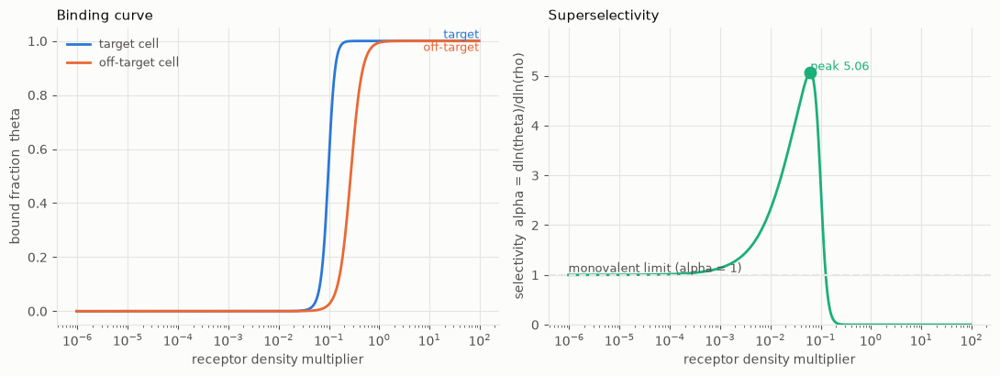

Table view (numerical summary of the plotted curves):
density multiplier  theta target  theta off-target
0.0000                    0.0000            0.0000
0.0000                    0.0000            0.0000
0.0001                    0.0000            0.0000
0.0009                    0.0000            0.0000
0.0094                    0.0001            0.0000
0.0947                    0.4726            0.0211
0.9523                    1.0000            0.9926
9.5779                    1.0000            1.0000
96.3328                   1.0000            1.0000


In [ ]:
#@title Multivalent selectivity: bound fraction and superselectivity (CPU)
binders = "B1:500:4, B2:2000:4, B3:5000:4" #@param {type:"string"}
target_density = "500, 300, 200" #@param {type:"string"}
offtarget_density = "500, 0, 0" #@param {type:"string"}
arm_reach_nm = 15.0 #@param {type:"number"}
ceff_uM = 100.0 #@param {type:"number"}
attach_cost_kT = 12.0 #@param {type:"number"}
#@markdown - `binders` format: `name:Kd_nM:valency`, comma-separated.
#@markdown - Surface densities are in receptors per square micrometer, in binder order.
#@markdown - You can use the geometry cell's exposed values for `arm_reach_nm` and `ceff_uM`.
#@markdown - `attach_cost_kT` is the translational/rotational entropy cost of approaching the surface.
#@markdown   Without this cost, superselectivity does not emerge; the typical range is 8-15 kT.
#@markdown - The sweep range automatically focuses on the transition region.
#@markdown - Superselectivity requires weak individual bonds and high valency; very tight
#@markdown   binders saturate the system at every density and reduce alpha below 1.
#@markdown - The model is entirely analytical and takes seconds.

# ---------------------------------------------------------------------------
# Model
#
# Martinez-Veracoechea & Frenkel (2011) framework, adapted by Dubacheva/Curk/Richter 2023
# and Tan/Orcutt-Jahns/Meyer 2021 for cell-selective targeting.
#
# One arm encounters N_i = rho_i * A_reach receptors within its accessible area.
# The arm's binding propensity   K_i = N_i * Ceff / Kd_i
# Particle weight at the surface  q = z0 * [ prod_i (1 + K_i)^v_i - 1 ]
# Bound fraction   theta = q / (1 + q)
#
# z0 = exp(-attach_cost_kT) represents the translational and
# rotational entropy cost of approaching the surface. Without this term,
# binding of any arm immediately binds the particle, removing threshold behavior.
#
# Superselectivity parameter   alpha = d ln(theta) / d ln(rho)
#   low density    : K_i << 1, q ~ rho, alpha -> 1  (monovalent-like)
#   transition     : K_i >> 1 but q << 1, q ~ rho^(total valency),
#                    alpha approaches total valency. This is the superselective region.
#   high density   : q >> 1, theta saturates, alpha -> 0
# Cell discrimination occurs in the transition region: cells above the threshold are retained, those below are released.
# ---------------------------------------------------------------------------

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

def parse_binders(s):
    out = []
    for part in s.split(","):
        part = part.strip()
        if not part:
            continue
        name, kd, val = (part.split(":") + ["1"])[:3]
        out.append((name.strip(), float(kd) * 1e-9, int(float(val))))
    return out

def parse_dens(s):
    return np.array([float(x) for x in s.replace(" ", "").split(",") if x])

bs = parse_binders(binders)
rho_on = parse_dens(target_density)
rho_off = parse_dens(offtarget_density)
if not (len(bs) == len(rho_on) == len(rho_off)):
    raise ValueError("binder count must match the lengths of the density lists")

CEFF = ceff_uM * 1e-6                       # M
A_REACH_UM2 = np.pi * (arm_reach_nm ** 2) / 1e6   # nm^2 -> square micrometers

Z0 = np.exp(-abs(attach_cost_kT))

def theta_of(rho_vec, scale=1.0):
    """Bound fraction; rho is in receptors per square micrometer."""
    logq = 0.0
    for (name, kd, val), rho in zip(bs, rho_vec):
        n_acc = max(rho * scale, 0.0) * A_REACH_UM2
        k_arm = n_acc * CEFF / kd
        logq += val * np.log1p(k_arm)
    q = Z0 * np.expm1(logq)
    return q / (1.0 + q)

print("BINDER DEFINITIONS")
print(pd.DataFrame([{"binder": n, "Kd (nM)": kd * 1e9, "valency": v,
                     "target cell (rec/um2)": ro, "off-target (rec/um2)": rf}
                    for (n, kd, v), ro, rf in zip(bs, rho_on, rho_off)]).to_string(index=False))
print()
print("arm reach: %.1f nm  ->  accessible area %.3g um2 | Ceff %.1f uM | z0 = %.3g (%.1f kT)"
      % (arm_reach_nm, A_REACH_UM2, ceff_uM, Z0, attach_cost_kT))
print("total valency: %d  ->  theoretical upper bound for alpha" % sum(v for _, _, v in bs))
print()

th_on, th_off = theta_of(rho_on), theta_of(rho_off)
print("BINDING")
print("  target cell      theta = %.4f" % th_on)
print("  off-target cell theta = %.4f" % th_off)
if th_off > 0:
    print("  discrimination ratio      = %.1f fold" % (th_on / th_off))
else:
    print("  discrimination ratio = no off-target cell binding")
print()

# single-binder reference: first binder only, same total valency
single = [(bs[0][0], bs[0][1], sum(v for _, _, v in bs))]
def theta_single(rho_vec, scale=1.0):
    name, kd, val = single[0]
    n_acc = max(rho_vec[0] * scale, 0.0) * A_REACH_UM2
    q = Z0 * np.expm1(val * np.log1p(n_acc * CEFF / kd))
    return q / (1.0 + q)
print("Single-target reference (only %s, valency %d):" % (single[0][0], single[0][2]))
print("  target cell theta = %.4f | off-target theta = %.4f"
      % (theta_single(rho_on), theta_single(rho_off)))
print("  Substantially better discrimination by the three-binder construct indicates AND-gate behavior.")
print()

# --- alpha sweep ------------------------------------------------------
# Center the sweep on the transition: first find the density
# multiplier at theta = 0.5 by bisection, then sweep around it. A fixed range
# leaves the entire curve on the saturated plateau for tight binders.
def find_half(rho_vec):
    lo, hi = -12.0, 6.0
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if theta_of(rho_vec, 10.0 ** mid) < 0.5:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

c = find_half(rho_on)
scales = np.logspace(c - 5.0, c + 3.0, 400)
th = np.array([theta_of(rho_on, s) for s in scales])
th_o = np.array([theta_of(rho_off, s) for s in scales])
ok = th > 1e-14
lt, ls_ = np.log(th[ok]), np.log(scales[ok])
alpha = np.gradient(lt, ls_)
i_max = int(np.argmax(alpha))
# best operating window: density where target/off-target discrimination widens
ratio = np.where(th_o > 1e-12, th / np.maximum(th_o, 1e-12), np.inf)
usable = (th > 0.05) & (th_o > 1e-12)
if usable.any():
    j = int(np.argmax(np.where(usable, ratio, -np.inf)))
    print("BEST OPERATING WINDOW")
    print("  density multiplier %.4g  ->  target theta = %.4f, off-target theta = %.4f, discrimination %.1f fold"
          % (scales[j], th[j], th_o[j], ratio[j]))
    k = int(np.argmax(th - th_o))
    print("  largest absolute difference: multiplier %.4g, target %.4f, off-target %.4f, difference %.4f"
          % (scales[k], th[k], th_o[k], th[k] - th_o[k]))
    print("  This multiplier identifies the receptor-density region where the design discriminates.")
    print("  Outside this density region, the construct does not discriminate between actual cells.")
    print()

print("SUPERSELECTIVITY")
print("  peak alpha = %.2f, around density multiplier %.3g (theta = %.4f)"
      % (alpha[i_max], scales[ok][i_max], th[ok][i_max]))
print("  alpha = 1 is monovalent behavior. Values substantially above 1 indicate a")
print("  sharper-than-linear binding response to receptor density, which provides cell discrimination.")
if alpha[i_max] < 1.05:
    print()
    print("  WARNING: alpha did not exceed 1. This usually means individual binders are too tight,")
    print("  saturating the system at every density. Superselectivity requires weak individual")
    print("  bonds and high valency (Dubacheva/Curk/Richter 2023). Increase Kd or")
    print("  valency to recover threshold behavior.")
print()

# --- plot --------------------------------------------------------------
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"     # verified categorical palette
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e2", "#fcfcfb"
for fam in ["DejaVu Sans", "Helvetica", "Arial"]:
    if any(f.name == fam for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = fam
        break
plt.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK2,
                     "figure.facecolor": SURF, "axes.facecolor": SURF})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(scales, th, color=S1, lw=2, label="target cell")
ax1.plot(scales, th_o, color=S2, lw=2, label="off-target cell")
ax1.set_xscale("log")
ax1.set_xlabel("receptor density multiplier")
ax1.set_ylabel("bound fraction  theta")
ax1.set_title("Binding curve", color=INK, loc="left", fontsize=11)
ax1.grid(True, color=GRID, lw=0.8)
ax1.set_axisbelow(True)
ax1.legend(frameon=False, labelcolor=INK2, fontsize=9)
ax1.annotate("target", (scales[-1], th[-1]), color=S1, fontsize=9,
             ha="right", va="bottom")
ax1.annotate("off-target", (scales[-1], th_o[-1]), color=S2, fontsize=9,
             ha="right", va="top")

ax2.plot(scales[ok], alpha, color=S3, lw=2)
ax2.axhline(1.0, color=GRID, lw=1.5, ls="--")
ax2.annotate("monovalent limit (alpha = 1)", (scales[ok][0], 1.0), color=INK2,
             fontsize=9, va="bottom")
ax2.plot([scales[ok][i_max]], [alpha[i_max]], "o", color=S3, ms=9)
ax2.annotate("peak %.2f" % alpha[i_max], (scales[ok][i_max], alpha[i_max]),
             color=S3, fontsize=9, ha="left", va="bottom")
ax2.set_ylim(0, float(np.max(alpha)) * 1.18)
ax2.set_xscale("log")
ax2.set_xlabel("receptor density multiplier")
ax2.set_ylabel("selectivity  alpha = dln(theta)/dln(rho)")
ax2.set_title("Superselectivity", color=INK, loc="left", fontsize=11)
ax2.grid(True, color=GRID, lw=0.8)
ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

print("Table view (numerical summary of the plotted curves):")
idx = np.linspace(0, len(scales) - 1, 9).astype(int)
print(pd.DataFrame({
    "density multiplier": np.round(scales[idx], 4),
    "theta target": np.round(th[idx], 4),
    "theta off-target": np.round(th_o[idx], 4),
}).to_string(index=False))

## 5. Deterministic value-flow summary — synthetic fixtures

This independent contract demonstration uses only the existing synthetic fixtures
in `tests/fixtures/value_flow_transfer/`. Its values are not taken from the design,
geometry or avidity cells above and do not describe a protein or binding outcome.

`f01_coordinate_distance/1` → `pointwise_measurement/1` → `transfer_value_flow`
(`value_flow_envelope/1` + `value_flow_receipt/1`) → `summarize_outcome`
→ `value_flow_demo_summary/1` → rendered lines and canonical JSON bytes.

Run cells 1/3 and 2/3 to show the existing `ACCEPTED`, `UNAVAILABLE` and `REJECTED`
summary categories. Cell 3/3 contains developer reproducibility checks.
Verifying loaders supply the inputs; no quantity is recomputed. These categories
apply only to this synthetic transfer, not to the external reference below.

This section needs a local repository checkout, but no preceding design cell,
GPU, Drive mount, download or inference. Set `VF_REPO_ROOT` if the working
directory is outside the checkout. `receipt_id` and `summary_id` include absolute
fixture paths and are reproducible within one checkout, not across checkouts.


In [ ]:
#@title Value-flow demo 1/3 — locate the checkout and load the fixture chain through verifying loaders
# Synthetic fixture only: a contract/integration demonstration, not a domain result.
# Needs no GPU and no other cell; mounts, downloads and installs nothing.
import sys
from pathlib import Path

VF_REPO_ROOT = None  # set to the checkout root (the directory holding src/structure_audit) if cwd is not inside it


def _vf_is_checkout(candidate):
    return ((candidate / "src" / "structure_audit" / "value_flow_demo_export.py").is_file()
            and (candidate / "tests" / "fixtures" / "value_flow_transfer").is_dir())


if VF_REPO_ROOT is not None:
    VF_ROOT = Path(VF_REPO_ROOT).resolve()
else:
    VF_ROOT = next((c for c in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                    if _vf_is_checkout(c)), None)
if VF_ROOT is None or not _vf_is_checkout(VF_ROOT):
    raise FileNotFoundError("no local checkout of this repository found; set VF_REPO_ROOT to the "
                            "directory holding src/structure_audit (nothing is downloaded or mounted)")
if str(VF_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(VF_ROOT / "src"))

import structure_audit
if Path(structure_audit.__file__).resolve().parent != VF_ROOT / "src" / "structure_audit":
    raise ImportError(f"structure_audit is already imported from {structure_audit.__file__}; "
                      "restart the runtime so the checkout's closed contracts are used")

from structure_audit.f01_coordinate_admission import load_f01_coordinate_distance
from structure_audit.pointwise_measurement import load_pointwise_measurement

VF_FIXTURES = VF_ROOT / "tests" / "fixtures" / "value_flow_transfer"
vf_f01_reference = load_f01_coordinate_distance(VF_FIXTURES / "f01_distance.json")
vf_producers = {label: load_pointwise_measurement(VF_FIXTURES / f"producer_{label}.json")
                for label in ("computed", "unavailable", "rejected")}

print(f"{'fixtures':<26}: {VF_FIXTURES.relative_to(VF_ROOT).as_posix()}")
print(f"{'f01_distance.json':<26}: {vf_f01_reference.status:<11} result_id {vf_f01_reference.result_id}")
for vf_label, vf_producer in vf_producers.items():
    print(f"{'producer_' + vf_label + '.json':<26}: {vf_producer.status:<11} result_id {vf_producer.result_id}")

In [ ]:
#@title Value-flow demo 2/3 — transfer through the public API, summarize with summarize_outcome
from structure_audit.provenance import hash_file
from structure_audit.value_flow_transfer import (
    PRODUCER_LAYOUT, REFERENCE_KIND, VALUE_NAMES, transfer_value_flow)
from structure_audit.value_flow_demo_export import summarize_outcome

# Identity fields named by value_flow_envelope/1 (a field list, not a value).
VF_IDENTITY_FIELDS = ("quantity_id", "quantity_definition_id", "context", "category", "unit", "scale")
# Use-event labels, reused verbatim from tests/test_value_flow_demo_export.py.
VF_PRODUCER_ID, VF_REFERENCE_ID = "syn-producer", "ref-f01"
VF_CONSUMER = {"consumer_id": "syn-consumer", "export_id": "syn-export-1"}


def vf_transfer(label, *, with_f01_reference):
    """Transfer one fixture producer; every expected identity is read from a verified document."""
    producer = vf_producers[label].to_dict()
    producer_path = (VF_FIXTURES / f"producer_{label}.json").resolve()
    reference_path = (VF_FIXTURES / "f01_distance.json").resolve()
    references = [{
        "reference_id": VF_REFERENCE_ID, "kind": REFERENCE_KIND,
        "path": str(reference_path), "sha256": hash_file(reference_path),
        "result_id": vf_f01_reference.result_id,
        "quantity_definition_id": vf_f01_reference.to_dict()["output_metric"]["quantity_definition_id"],
    }] if with_f01_reference else []
    return transfer_value_flow(
        producer={"producer_id": VF_PRODUCER_ID, "path": str(producer_path),
                  "sha256": hash_file(producer_path), "layout": PRODUCER_LAYOUT},
        expected={"producer_result_id": producer["result_id"],
                  "configuration": {key: producer["parameters"][key]
                                    for key in ("profile_id", "profile_version")},
                  "quantities": {name: {key: producer["outputs"][name][key] for key in VF_IDENTITY_FIELDS}
                                 for name in VALUE_NAMES}},
        measurement_references=references,
        consumer=dict(VF_CONSUMER))


# Only the COMPUTED producer consumed the F01 distance. The other two record no distance
# or a different one, so declaring the reference would stop them at MEASUREMENT_REFERENCES;
# they are transferred without it, as in the test suite, so their own status decides.
vf_outcomes = {"ACCEPTED": vf_transfer("computed", with_f01_reference=True),
               "UNAVAILABLE": vf_transfer("unavailable", with_f01_reference=False),
               "REJECTED": vf_transfer("rejected", with_f01_reference=False)}
vf_summaries = {outcome: summarize_outcome(result) for outcome, result in vf_outcomes.items()}

vf_summary = vf_summaries["ACCEPTED"]
vf_document = vf_summary.to_dict()
vf_bytes = vf_summary.to_json_bytes()
print("\n".join(vf_summary.render_lines()))
print()
print("summary_id           :", vf_summary.summary_id)
print("outcome              :", vf_summary.outcome)
print("producer result id   :", vf_document["identity_chain"]["producer_result_id"])
print("F01 reference id(s)  :", ", ".join(vf_document["identity_chain"]["f01_reference_result_ids"]) or "none carried")
print("canonical JSON bytes :", len(vf_bytes))
print()
for vf_outcome in ("UNAVAILABLE", "REJECTED"):
    vf_other = vf_summaries[vf_outcome]
    print(f"{vf_outcome:<11} reason {vf_other.to_dict()['status']['reason']:<26} "
          f"summary_id {vf_other.summary_id}  bytes {len(vf_other.to_json_bytes())}")

In [ ]:
#@title Developer check — value-flow 3/3: serialization, reload and status categories
import tempfile
from structure_audit.value_flow_demo_export import load_value_flow_demo_summary

# The accepted summary carries the loaded producer result and F01 reference identities.
assert vf_document["identity_chain"]["producer_result_id"] == vf_producers["computed"].result_id
assert vf_document["identity_chain"]["f01_reference_result_ids"] == [vf_f01_reference.result_id]

# 1. Repeated serialization is byte-identical: same object, re-summarized outcome, fresh transfer.
assert vf_summary.to_json_bytes() == vf_bytes
assert summarize_outcome(vf_outcomes["ACCEPTED"]).to_json_bytes() == vf_bytes
assert summarize_outcome(vf_transfer("computed", with_f01_reference=True)).to_json_bytes() == vf_bytes

# 2. Export, reload through the verifying loader and reserialize: byte-identical per category.
with tempfile.TemporaryDirectory() as vf_tmp:
    for vf_outcome, vf_other in vf_summaries.items():
        vf_path = Path(vf_tmp) / f"{vf_outcome}.json"
        vf_path.write_bytes(vf_other.to_json_bytes())
        vf_reloaded = load_value_flow_demo_summary(vf_path)
        assert vf_reloaded.to_json_bytes() == vf_other.to_json_bytes(), vf_outcome
        assert (vf_reloaded.summary_id, vf_reloaded.outcome) == (vf_other.summary_id, vf_outcome)

# 3. All three status categories are demonstrated and stay distinguishable.
assert [s.outcome for s in vf_summaries.values()] == ["ACCEPTED", "UNAVAILABLE", "REJECTED"]
assert len({s.summary_id for s in vf_summaries.values()}) == 3
assert len({s.to_dict()["status"]["reason"] for s in vf_summaries.values()}) == 3

print("all assertions passed")
print("  repeated serialization  byte-identical (same object, re-summarized, fresh transfer)")
print("  reload + reserialize    byte-identical for ACCEPTED, UNAVAILABLE, REJECTED")
print("  status categories       ACCEPTED, UNAVAILABLE, REJECTED all demonstrated and distinct")

## 6. Publication summary — independent synthetic lanes

The existing ledger presents alignment publication and the already-produced
value-flow summaries side by side. Both use committed synthetic fixtures and
public APIs; neither is a scientific, ranking or optimization result.

- **Alignment lane:** `tests/fixtures/alignment_publication/` →
  `publish_alignment_evidence` → `alignment_evidence_envelope/1` →
  `publish_alignment_handoff` → `alignment_handoff_record/1`.
- **Value-flow lane:** reuse the preceding `value_flow_demo_summary/1` documents.

Run value-flow cells 1/3 and 2/3 first in the same runtime. The alignment fixture
pack is pinned by `tests/test_alignment_publication_fixtures.py`; only
`artifact.path` and `config.allowed_input_roots` are injected at runtime.

No values are joined, compared, calculated or transferred between lanes.
Alignment identities do not depend on checkout location; value-flow summary
identities do. Cell 5/5 contains developer reproducibility checks. No consumer is
executed, and nothing is mounted, downloaded or installed by this section.

### Alignment evidence and handoff records


In [ ]:
#@title Publication lanes 1/5 — preconditions and alignment fixtures
# Synthetic fixtures only: a contract/integration demonstration, not a domain result.
if "VF_ROOT" not in globals() or "vf_summaries" not in globals():
    raise NameError("run the value-flow demo cells 1/3 and 2/3 first; this section reuses their "
                    "checkout location and value_flow_demo_summary/1 documents")

from structure_audit import alignment_publication as al_publication
from structure_audit import validation as al_validation

al_fixtures = (VF_ROOT / "tests" / "fixtures" / "alignment_publication").resolve()
al_requests = al_validation.read_json(al_fixtures / "requests.json")["cases"]
al_reference_sets = {entry["name"]: entry["references"]
                     for entry in al_validation.read_json(al_fixtures / "references.json")["sets"]}


def al_bind(case):
    """Inject exactly the two runtime fields; every other request field is committed in the fixture."""
    return {"artifact": {**case["artifact"], "path": str(al_fixtures / case["source_file"])},
            "config": {**case["config"], "allowed_input_roots": [str(al_fixtures)]}}


print(f"{'fixtures':<22}{al_fixtures.relative_to(VF_ROOT).as_posix()}")
print(f"{'request cases':<22}{', '.join(case['name'] for case in al_requests)}")
for al_set_name, al_references in al_reference_sets.items():
    print(f"{'reference set ' + al_set_name:<22}"
          f"{', '.join(r['component_kind'] + ':' + r['component_id'] for r in al_references)}")

In [ ]:
#@title Publication lanes 2/5 — Lane A evidence envelopes
al_envelopes = {case["name"]: al_publication.publish_alignment_evidence(**al_bind(case))
                for case in al_requests}

for al_name, al_envelope in al_envelopes.items():
    al_diagnostic = al_envelope.to_dict()["reader_diagnostic"]  # only its closed code is printed
    print(f"{al_name:<12} {al_envelope.status:<11} reason {al_envelope.reason or '-':<25} "
          f"reader_code {al_diagnostic['code'] if al_diagnostic else '-':<29} "
          f"envelope_id {al_envelope.envelope_id} bytes {len(al_envelope.to_json_bytes())}")

al_source_fields = al_envelopes["available"].to_dict()["source_fields"]
print()
print(f"{'selected_occurrence':<20}{al_source_fields['/query']['selected_occurrence']}")
print(f"{'occurrence ids':<20}"
      f"{', '.join(entry['record_occurrence_id'] for entry in al_source_fields['/occurrence_mapping'])}")

In [ ]:
#@title Publication lanes 3/5 — Lane A handoff records
# (fixture case, fixture reference set) pairs: READY, BLOCKED and UNAVAILABLE.
al_handoff_plan = (("available", "ready"), ("available", "blocked"), ("unavailable", "ready"))
al_handoffs = {}
for al_case_name, al_set_name in al_handoff_plan:
    al_envelope = al_envelopes[al_case_name]
    al_handoffs[f"{al_case_name}/{al_set_name}"] = al_publication.publish_alignment_handoff(
        envelope=al_envelope, expected_envelope_id=al_envelope.envelope_id,
        references=al_reference_sets[al_set_name])

for al_label, al_record in al_handoffs.items():
    al_record_data = al_record.to_dict()
    print(f"{al_label:<19} {al_record.status:<11} reason {al_record_data['reason'] or '-':<25} "
          f"handoff_id {al_record.handoff_id} envelope_id {al_record.envelope_id} "
          f"bytes {len(al_record.to_json_bytes())}")
    for al_reference in al_record_data["references"]:
        al_locator = al_reference["source_locator"]
        print(f"  {al_reference['component_kind']:<19} {al_reference['component_id']:<24} "
              f"{al_reference['resolution']:<13} locator {al_locator['record_occurrence_id'] if al_locator else '-'}")

### Existing lane ledger — alignment and value-flow

Both lanes are printed in a fixed order with the same columns. No value is joined, compared, calculated or transferred between the lanes.

In [ ]:
#@title Publication lanes 4/5 — lane ledger (side by side, no join)
al_ledger = (
    [("value-flow", s.to_dict()["schema_version"], s.outcome, s.to_dict()["status"]["reason"],
      s.summary_id, len(s.to_json_bytes())) for s in vf_summaries.values()]
    + [("alignment", e.to_dict()["schema_version"], e.status, e.reason, e.envelope_id,
        len(e.to_json_bytes())) for e in al_envelopes.values()]
    + [("alignment", h.to_dict()["schema_version"], h.status, h.to_dict()["reason"], h.handoff_id,
        len(h.to_json_bytes())) for h in al_handoffs.values()])

print(f"{'lane':<11}{'document':<30}{'status':<12}{'reason':<28}{'id':<65}bytes")
for al_row in al_ledger:
    print(f"{al_row[0]:<11}{al_row[1]:<30}{al_row[2]:<12}{al_row[3] or '-':<28}{al_row[4]:<65}{al_row[5]}")

In [ ]:
#@title Developer check — publication lanes 5/5: reproducibility and status boundaries
import tempfile as al_tempfile
from structure_audit import value_flow_demo_export as al_value_flow_export


def al_passed(name):
    print(f"check {name:<34} passed")


# 1. Repeated serialization is byte-identical, including a fresh publication from the same inputs.
for al_case in al_requests:
    al_envelope = al_envelopes[al_case["name"]]
    assert al_envelope.to_json_bytes() == al_envelope.to_json_bytes()
    assert (al_publication.publish_alignment_evidence(**al_bind(al_case)).to_json_bytes()
            == al_envelope.to_json_bytes()), al_case["name"]
for al_case_name, al_set_name in al_handoff_plan:
    al_record = al_handoffs[f"{al_case_name}/{al_set_name}"]
    assert al_record.to_json_bytes() == al_record.to_json_bytes()
    assert (al_publication.publish_alignment_handoff(
        envelope=al_envelopes[al_case_name], expected_envelope_id=al_envelopes[al_case_name].envelope_id,
        references=al_reference_sets[al_set_name]).to_json_bytes() == al_record.to_json_bytes())
for al_outcome_name, al_summary in vf_summaries.items():
    assert (al_value_flow_export.summarize_outcome(vf_outcomes[al_outcome_name]).to_json_bytes()
            == al_summary.to_json_bytes()), al_outcome_name
al_passed("repeated serialization")

# 2. Export, reload through the public verifying loaders and reserialize: byte-identical.
with al_tempfile.TemporaryDirectory() as al_tmp:
    for al_loader, al_documents in ((al_publication.load_alignment_evidence_envelope, al_envelopes),
                                    (al_publication.load_alignment_handoff_record, al_handoffs),
                                    (al_value_flow_export.load_value_flow_demo_summary, vf_summaries)):
        for al_index, al_document in enumerate(al_documents.values()):
            al_path = Path(al_tmp) / f"{al_loader.__name__}-{al_index}.json"
            al_path.write_bytes(al_document.to_json_bytes())
            assert al_loader(al_path).to_json_bytes() == al_document.to_json_bytes(), al_path.name
al_passed("reload and reserialize")

# 3. Every handoff record re-derives from its own envelope.
for al_case_name, al_set_name in al_handoff_plan:
    al_record = al_handoffs[f"{al_case_name}/{al_set_name}"]
    assert al_record.envelope_id == al_envelopes[al_case_name].envelope_id
    al_publication.verify_alignment_handoff(al_record, al_envelopes[al_case_name])
al_passed("handoff linkage")

# 4. Status categories are visible and distinct within each lane.
assert [e.status for e in al_envelopes.values()] == ["AVAILABLE", "UNAVAILABLE", "UNSUPPORTED", "REJECTED"]
assert len({e.envelope_id for e in al_envelopes.values()}) == 4
assert [h.status for h in al_handoffs.values()] == ["READY", "BLOCKED", "UNAVAILABLE"]
assert len({h.handoff_id for h in al_handoffs.values()}) == 3
assert [s.outcome for s in vf_summaries.values()] == ["ACCEPTED", "UNAVAILABLE", "REJECTED"]
assert len({s.summary_id for s in vf_summaries.values()}) == 3
al_passed("distinct status categories")

# 5. BLOCKED and UNAVAILABLE states are explicit.
al_blocked = al_handoffs["available/blocked"].to_dict()
assert al_blocked["reason"] == "REQUIRED_REFERENCE_ABSENT"
assert any(r["resolution"] == "ABSENT" and r["source_locator"] is None for r in al_blocked["references"])
al_unavailable = al_envelopes["unavailable"].to_dict()
assert (al_unavailable["reason"], al_unavailable["source_fields"]) == ("SOURCE_UNREADABLE", None)
assert {r["resolution"] for r in al_handoffs["unavailable/ready"].to_dict()["references"]} == {"NOT_EVALUATED"}
al_passed("blocked and unavailable states")

# 6. No absolute runtime path (checkout root, fixture directory, injected source path) in alignment bytes.
al_runtime_paths = {str(VF_ROOT), str(al_fixtures)} | {al_bind(c)["artifact"]["path"] for c in al_requests}
for al_document in [*al_envelopes.values(), *al_handoffs.values()]:
    assert not any(p.encode() in al_document.to_json_bytes() for p in al_runtime_paths)
al_passed("no absolute runtime path")

## Collected artifact references and manual selection

Read-only collection surface (`notebook_artifact_inventory/1`). It lists artifact
references already produced elsewhere together with the metadata already declared for
them, and records which identifiers a reader selects by hand.

Collection is not evaluation and manual selection is not declaration. References are
opaque text and are never opened or resolved; declared metadata is carried verbatim and
never interpreted. Nothing here scores, ranks, sorts by quality, filters, recommends or
selects automatically, and presence in the list is not evidence about an item. Whether
anything may be declared from a selected identifier is decided entirely by the separate
intake seam, which applies its own contract and may refuse.


In [ ]:
from structure_audit.notebook_artifact_inventory import (
    collect_artifact_inventory, render_inventory_lines,
)

# Declared literally here. Nothing is discovered, globbed, listed or read: edit this list
# by hand to describe references you already have. declared_metadata is carried verbatim.
ARTIFACT_ITEMS = [
    {"item_id": "run-a", "reference": "external_artifacts/run-a",
     "declared_metadata": {}},
    {"item_id": "run-b", "reference": "external_artifacts/run-b",
     "declared_metadata": {}},
]

inventory = collect_artifact_inventory(ARTIFACT_ITEMS)
print("\n".join(render_inventory_lines(inventory)))


In [ ]:
from structure_audit.notebook_artifact_inventory import (
    build_handoff_manifest, render_selection_lines, select_inventory_items,
)

# Type the identifiers you choose, in the order you want them carried forward. [] is a
# valid, explicitly empty selection and does not mean every item. A repeated or unknown
# identifier is refused rather than repaired.
SELECTED_IDS = []

selection = select_inventory_items(inventory, SELECTED_IDS)
print("\n".join(render_selection_lines(selection)))

# Reference-only: it names the intake seam and carries the identifiers verbatim. No
# candidate, declaration, slot mapping or combination is constructed here.
handoff = build_handoff_manifest(inventory, selection)
print()
print("handoff target_seam:", handoff.target_seam)
print("handoff bytes:", len(handoff.to_json_bytes()))


## Structure artifact pack for external inspection

Reference-only view (`structure_artifact_pack/1`) over an artifact inventory or manual
selection already built by the collection layer. It is a list you carry by hand to an
external inspection tool, such as a molecular viewer.

Every reference and metadata value is carried verbatim and was never opened, resolved or
read. No tool command, script, session, selection expression, alignment or superposition is
generated, because writing one would assert what a reference names, and this view never
reads one.

These are inspection references. They are **not** validated bound complexes, **not** best or
representative poses, **not** docked, superposed, minimized or refined structures, and
**not** binding, contact, affinity or avidity proofs. Presence in the pack is not evidence
about an item, and pack order is the source document's order, not a preference.


In [ ]:
from structure_audit.structure_artifact_pack import build_artifact_pack, render_pack_lines

# `selection` (or `inventory`) comes from the collection cells above. Nothing is
# re-collected, re-selected or reordered here, and no reference is opened.
pack = build_artifact_pack(selection)
print("\n".join(render_pack_lines(pack)))

# The carried reference text, in the source document's own order. Decide by hand what, if
# anything, to open in your inspection tool.
print()
for reference in pack.references():
    print(reference)


## Candidate combinations table

Descriptive restatement of a finished `cassette_candidate_priority/1` report
(`candidate_combinations_table/1`), optionally joined to the combinations a
`demo_candidate_manifest/1` document already declared.

This view computes no order and mints no value. Ranked rows follow the source report's own
groups and members arrays; excluded rows follow its own excluded array, in a separate
section, and are never hidden. `rank`, `geometry_tier`, `evidence_coverage`,
`ineligibility_reason` and `vetoed_slots` are carried from the source unchanged. Nothing
here sorts, scores, weights, combines, filters or recommends, and a declared row limit is a
display cut over the order the source already fixed, never a selection or a shortlist.
Equal rank means equal tier, exactly as the source says.


**Input unavailable in this notebook — the next cell is not run here.**

This notebook currently exposes no finished `cassette_candidate_priority/1` document and no
`demo_candidate_manifest/1` document for this surface. Nothing is computed, manufactured or
re-run here: no priority, batch, scenario-comparison or evidence-completeness pipeline is
started, and no substitute document is constructed.

The next cell, `combinations-table-01-render`, is therefore a paste-ready template. It must
not be executed in this notebook state; run it only after a completed serialized
`cassette_candidate_priority/1` document has been explicitly assigned to `PRIORITY_DOCUMENT`
(and, optionally, a `demo_candidate_manifest/1` document to `MANIFEST_DOCUMENT`). Until then
the table layer refuses the input by contract rather than producing a partial table.


In [ ]:
from structure_audit.candidate_combinations_table import (
    build_combinations_table, render_table_lines,
)

# PRIORITY_DOCUMENT is a finished cassette_candidate_priority/1 document, as a dict or its
# canonical bytes, produced earlier by its own layer. MANIFEST_DOCUMENT is optional.
# Nothing is recomputed here and no producer is imported.
table = build_combinations_table(
    PRIORITY_DOCUMENT,
    manifest_document=MANIFEST_DOCUMENT,
    row_limit=None,           # None shows every ranked row; an int is a display cut only
)
print("\n".join(render_table_lines(table)))


## 7. Optional AF3-ReD external structure reference

This final presentation reuses the already-produced value-flow summary lines
unchanged. Its two existing cases show the report without a reference, then with
the supplied historical AF3-ReD runtime observation. They are composition
examples of the same report, not a new result or a combined acceptance state.

**Optional · separate provenance · no admission or ranking effect.** The reference
stays `candidate`. An absent reference does not block the existing report. No
relationship to any candidate, geometry, state or avidity result is established.
Runtime validation is not scientific validation; this section performs no new
validation, artifact access or metadata completion.


In [ ]:
#@title Optional external reference — absent and supplied historical reference
from structure_audit.demo_external_reference import ExternalStructureReference, build_demo_report

# Caller supplies the existing display lines; the original summary is unchanged.
vf_external_summary_lines = vf_summary.render_lines()

print("Case 1 — no external reference (optional; existing report still runs)")
vf_external_absent_report = build_demo_report(vf_external_summary_lines)
print("\n".join(vf_external_absent_report.render_lines()))

vf_external_reference = ExternalStructureReference(
    provider="af3-red",
    profile="af3_native_v1",
    artifact_id="5b4690580b352de100439cc68cb460847c4f4729c3b9151ca6ba739f8ce2aad7",
    observed_sha256="58f38cc8f279fb827851c27ff735bdc4b310ca22276a6a2cf8ebbb2414a882ed",
    source_status="candidate",
    read_completed=True,
    execution_state="completed",
    validation_status="passed_with_nonfatal_observations",
    non_admission_reasons=[
        "af3red_execution_declaration_missing",
        "bias_sigma_unknown",
        "bias_weight_unknown",
    ],
)
vf_external_supplied_report = build_demo_report(vf_external_summary_lines, vf_external_reference)
print("\nCase 2 — optional historical reference; separate provenance, no admission effect")
print("No relationship to candidate, geometry, state or avidity results is established.")
print("\n".join(vf_external_supplied_report.render_lines()))


## 8. Synthetic scenario demonstration

This is a fixed synthetic demonstration.

Outputs are scenario-sensitive ranking observations, not biological, physical,
clinical, structural or binding-performance truth.

This ordered three-slot candidate is a stronger test-priority hypothesis under the declared geometry/state inputs and the explicitly available structure-evidence record.

This ordering is a deterministic restatement of declared inputs and finished Phase 2 results. It is not a claim about receptor biology, abundance, accessibility, expression, membrane context, glycosylation, or dynamics; not about affinity, KD, kinetics, occupancy, avidity magnitude, binding probability, efficacy, safety, specificity, or experimental success. A structure prediction or external artifact referenced here is not ground truth, and the presence of an AF3-ReD evidence record is not evidence of candidate quality. A NOT_VETOED Phase 2 outcome carries exactly the scope of 20.7.3 N0 and nothing further.

Test-priority ordering - declared geometry/state and declared evidence coverage only. Rank is a function of the Phase 2 geometry/state tier alone. Evidence coverage is reported, never ranked on. Equal rank means equal tier, not equivalence. Listing position within a rank is caller sequence, not precedence.

In [ ]:
#@title 8.1 Minimal import and run — one facade call, retained for every later group
from demo_candidate_scenarios import build_synthetic_demo, render_lines

result = build_synthetic_demo()
rendered = render_lines(result)
# The renderer's own section marker; it splits the retained rendering for groups 8.3-8.5.
comparison_start = rendered.index("Declared-scenario comparison")

In [ ]:
#@title 8.2 Scenario declarations — caller-declared run references
for scenario in result.scenarios:
    print(f"{scenario.scenario_id} — {scenario.label}; run {scenario.evaluation_run_ref}")
print()
print("Run references are caller-declared associations, not independently verified"
      " producer provenance.")

### 8.3 Priority and exclusion

Test-priority ordering - declared geometry/state and declared evidence coverage only. Rank is a function of the Phase 2 geometry/state tier alone. Evidence coverage is reported, never ranked on. Equal rank means equal tier, not equivalence. Listing position within a rank is caller sequence, not precedence.

Listing position does not select a winner.

In [ ]:
#@title 8.3 Priority and exclusion — every scenario, in source order
for line in rendered[:comparison_start]:
    print(line)

In [ ]:
#@title 8.4 Scenario comparison — existing table and movement/eligibility summary
for line in rendered[comparison_start:-1]:
    print(line)

This ordered three-slot candidate is a stronger test-priority hypothesis under the declared geometry/state inputs and the explicitly available structure-evidence record.

This ordering is a deterministic restatement of declared inputs and finished Phase 2 results. It is not a claim about receptor biology, abundance, accessibility, expression, membrane context, glycosylation, or dynamics; not about affinity, KD, kinetics, occupancy, avidity magnitude, binding probability, efficacy, safety, specificity, or experimental success. A structure prediction or external artifact referenced here is not ground truth, and the presence of an AF3-ReD evidence record is not evidence of candidate quality. A NOT_VETOED Phase 2 outcome carries exactly the scope of 20.7.3 N0 and nothing further.

In [ ]:
#@title 8.5 Bounded conclusion — the existing rendered conclusion, verbatim
print(rendered[-1])

## Appendix — RFdiffusion input notation

Use `contigs` to define continuous chains. Use a `:` to define multiple contigs and a `/` to define multiple segments within a contig.
For example:

**unconditional**
- `contigs='100'` - diffuse **monomer** of length 100
- `contigs='50:100'` - diffuse **hetero-oligomer** of lengths 50 and 100
- `contigs='50'` `symmetry='cyclic'` `order=2` - make two copies of the defined contig(s) and add a symmetry constraint, for **homo-oligomeric** diffusion.

**binder design**
- `contigs='A:50'` `pdb='4N5T'` - diffuse a **binder** of length 50 to chain A of defined PDB.
- `contigs='E6-155:70-100'` `pdb='5KQV'` `hotspot='E64,E88,E96'` - diffuse a **binder** of length 70 to 100 (sampled randomly) to chain E and defined hotspot(s).

**motif scaffolding**
 - `contigs='40/A163-181/40'` `pdb='5TPN'`
 - `contigs='A3-30/36/A33-68'` `pdb='6MRR'` - diffuse a loop of length 36 between two segments of defined PDB ranges.

**partial diffusion**
- `contigs=''` `pdb='6MRR'` - noise all coordinates
- `contigs='A1-10'` `pdb='6MRR'` - keep first 10 positions fixed, noise the rest
- `contigs='A'` `pdb='1SSC'` - fix chain A, noise the rest

**Hints and tips**
- `pdb=''` leave blank to get an upload prompt
- `contigs='50-100'` use dash to specify a range of lengths to sample from
